# 📡 Telecom Customer Churn Analysis
## A Full-Stack Data Science Portfolio Project

**Author:** [Your Name]  
**Dataset:** Telecom Customer Churn (~100K rows)  
**Goal:** Predict customer churn, understand its drivers, and translate predictions into actionable business strategy.

---

### Project Scope
| Phase | Topics Covered |
|---|---|
| 1. Setup & Data Loading | Config, imports, data ingestion, ID handling |
| 2. Data Quality | Missingness, duplicates, type issues, target distribution |
| 3. Feature Engineering | Tenure bands, charge ratios, interaction terms |
| 4. Exploratory Analysis | Descriptive stats, churn rates by segment |
| 5. Statistical Testing | Chi-square (categorical), Mann-Whitney + t-test (numeric) |
| 6. Correlation & Multicollinearity | Heatmaps, VIF analysis |
| 7. Preprocessing Pipelines | Imputation, scaling, encoding |
| 8. Class Imbalance | SMOTE + class weights comparison |
| 9. Model Training & CV | Dummy, LogReg, RF, GBM, XGBoost |
| 10. Hyperparameter Tuning | GridSearchCV on best model |
| 11. Test Set Evaluation | ROC-AUC, PR-AUC, Brier, classification report |
| 12. Threshold Optimization | Precision-recall tradeoff |
| 13. Calibration | Reliability diagram |
| 14. Interpretability | Feature importances, SHAP values |
| 15. Error Analysis | FP/FN breakdown by segment |
| 16. Survival Analysis | Kaplan-Meier churn curves by segment |
| 17. Revenue at Risk | Expected monthly revenue loss |
| 18. Cumulative Gains & Lift | Decile table |
| 19. Uplift / Persuadable Churn | Separating likely-churners from persuadable ones |
| 20. Retention Strategy Sim | Multi-scenario profitability simulation |
| 21. Risk-Value Segmentation | 2×2 priority matrix |
| 22. Business Recommendations | Actionable playbook |
| 23. Limitations & Next Steps | Honest caveats |
| 24. Executive Summary | KPIs and export |


## 🔧 Section 1 — Environment Setup & Imports

Before any analysis begins, we establish our full Python environment. This cell loads every library we'll need across the entire project — no hidden imports later.

**Why this matters:**  
Loading all dependencies upfront makes the notebook reproducible. Anyone cloning this repo can run `pip install -r requirements.txt` and be guaranteed a working environment.

**Key library choices:**
- **`pandas` / `numpy`** — the backbone of all tabular data manipulation
- **`sklearn`** — our primary ML framework for preprocessing, modelling, and evaluation
- **`scipy`** — statistical hypothesis testing (chi-square, Mann-Whitney U)
- **`statsmodels`** — Variance Inflation Factor (VIF) for multicollinearity detection
- **`shap`** *(optional)* — model explainability via Shapley values; crucial for making black-box models interpretable to business stakeholders
- **`lifelines`** *(optional)* — survival analysis; gives us a time-based view of when customers churn
- **`imbalanced-learn`** *(optional)* — SMOTE oversampling to handle the class imbalance problem

Optional packages are gracefully handled with `try/except` so the notebook runs even in minimal environments.


In [2]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, brier_score_loss,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Optional dependencies — installed where available
try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("XGBoost available.")
except ImportError:
    xgb_available = False
    print("XGBoost not installed; skipping.")

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_available = True
    print("imbalanced-learn available.")
except ImportError:
    smote_available = False
    print("imbalanced-learn not installed; SMOTE comparison will be skipped.")

try:
    import shap
    shap_available = True
    print("SHAP available.")
except ImportError:
    shap_available = False
    print("SHAP not installed; falling back to native importances.")

try:
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test
    lifelines_available = True
    print("lifelines available.")
except ImportError:
    lifelines_available = False
    print("lifelines not installed; survival analysis will be skipped.")

print("All imports done.")

XGBoost available.
imbalanced-learn available.
SHAP not installed; falling back to native importances.
lifelines not installed; survival analysis will be skipped.
All imports done.


## ⚙️ Section 2 — Project Configuration

Rather than scattering magic numbers throughout the code, all business assumptions and parameters are defined here in one place.

**Key design decisions:**
- `AVG_MONTHLY_REVENUE = $65` — used as a fallback when `MonthlyCharges` is missing; based on industry average for mid-tier telecom plans
- `MONTHLY_RETENTION_CAMPAIGN_COST = $20` — typical cost estimate for a personalised outreach (call centre time + offer discount); this is the breakeven input for our ROI model
- `RETENTION_SUCCESS_RATES = [10%, 20%, 25%, 30%]` — industry retention success rates typically fall between 10–35%; we simulate all to find the robust sweet spot
- `TARGET_FRACTIONS` — controls how aggressively we intervene; targeting too broadly wastes budget on customers who would have stayed anyway

**Business insight:** These parameters are the levers a business analyst or product manager controls. Changing them instantly re-runs the entire revenue simulation — this is where the model becomes a business decision tool, not just an accuracy benchmark.


In [3]:
# ============================================================
# CELL 2 — CONFIG
# ============================================================

# --- Paths ---
DATA_PATH   = Path("data/synthetic_customer_churn_100k.csv")  # ← adjust if needed
OUTPUT_DIR  = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# --- Column config ---
TARGET_COL  = "Churn"
ID_COLS     = ["CustomerID"]
RANDOM_STATE = 42

# --- Business assumptions ---
AVG_MONTHLY_REVENUE          = 65      # fallback if MonthlyCharges not in data
MONTHLY_RETENTION_CAMPAIGN_COST = 20   # $ per customer contacted
RETENTION_SUCCESS_RATES      = [0.10, 0.20, 0.25, 0.30]
CAMPAIGN_COST_OPTIONS        = [10, 20, 30]
TARGET_FRACTIONS             = [0.02, 0.05, 0.10, 0.15, 0.20]

# --- Plot style ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

print("Config loaded.")

Config loaded.


## 🛠️ Section 3 — Helper Functions

A set of reusable utility functions that keep downstream cells concise and consistent.

**Notable functions:**
- `churn_rate_table()` — computes churn rate *and* **lift vs. average** per segment. Lift tells us how much riskier (or safer) a group is relative to the baseline. A lift of 2.5x on month-to-month contracts, for example, means that segment churns at 2.5× the average rate — an immediately actionable insight.
- `safe_target_mapping()` — handles real-world messiness where the churn column might be "Yes/No", "1/0", or "True/False" across different data exports
- `risk_band()` / `value_band()` — used later to place customers into the risk-value priority matrix for campaign targeting
- `cramers_v()` — measures the *strength* of association between a categorical variable and churn (not just whether it's statistically significant)


In [4]:
# ============================================================
# CELL 3 — HELPER FUNCTIONS
# ============================================================

def print_section(title):
    bar = "=" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

def churn_rate_table(data, group_col, target_col):
    """Return count, churn rate, and lift per category."""
    overall = data[target_col].mean()
    temp = (
        data.groupby(group_col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"count": "n", "mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )
    temp["churn_rate_pct"] = (temp["churn_rate"] * 100).round(2)
    temp["lift_vs_avg"]    = (temp["churn_rate"] / overall).round(3)
    return temp

def safe_target_mapping(series):
    """Robustly map churn column to 0/1."""
    if series.dtype == "object":
        mapped = series.astype(str).str.strip().str.lower().map({
            "yes": 1, "true": 1, "1": 1, "churn": 1,
            "no": 0,  "false": 0, "0": 0, "stay": 0
        })
        if mapped.notna().sum() > 0:
            return mapped
    return series

def risk_band(prob):
    if prob < 0.25:  return "Low"
    if prob < 0.50:  return "Medium"
    if prob < 0.75:  return "High"
    return "Critical"

def value_band(x, q33=None, q67=None):
    """3-tier value band using data-driven quantiles."""
    if pd.isna(x): return "Unknown"
    if q33 and q67:
        if x < q33: return "Low"
        if x < q67: return "Medium"
        return "High"
    if x < 40: return "Low"
    if x < 80: return "Medium"
    return "High"

def cramers_v(confusion_matrix_arr):
    """Cramér's V effect size from a contingency table."""
    chi2 = chi2_contingency(confusion_matrix_arr)[0]
    n    = confusion_matrix_arr.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix_arr.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

print("Helpers defined.")

Helpers defined.


## 📥 Section 4 — Data Loading

We load the raw dataset and immediately apply two important normalisation steps before any analysis.

**Column name standardisation** (`strip + replace spaces with underscores`) prevents silent errors when column names contain invisible leading/trailing spaces — a common issue with CSV exports from CRM systems.

**Flexible target encoding** handles the common real-world problem where different data pipelines encode churn differently (e.g., "Yes"/"No" vs. 1/0 vs. "churn"/"stay"). The `safe_target_mapping()` function handles all variants automatically.

**ID column removal** — `CustomerID` and similar identifier columns are dropped before modelling. Including them would cause data leakage: the model could memorise customer IDs rather than learning genuine patterns, producing fraudulently high validation scores.

> 💡 **Business context:** With ~100,000 rows, this is a sizeable dataset — enough for robust statistical testing and generalisation. Smaller datasets (< 5K rows) would require more conservative model choices.


In [5]:
# ============================================================
# CELL 4 — LOAD DATA
# ============================================================
print_section("1. LOAD DATA")

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

# Standardise column names
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Flexible target detection
if TARGET_COL not in df.columns:
    matches = [c for c in df.columns if c.lower() == TARGET_COL.lower()]
    if matches:
        TARGET_COL = matches[0]
        print(f"Target column matched as: {TARGET_COL}")

# Drop ID columns
drop_cols = [c for c in ID_COLS if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Encode target
df[TARGET_COL] = safe_target_mapping(df[TARGET_COL])
if not pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    unique_vals = df[TARGET_COL].dropna().unique()
    if len(unique_vals) == 2:
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        df[TARGET_COL] = df[TARGET_COL].map(mapping)
        print("Auto-mapped target:", mapping)

print("Final shape:", df.shape)
print(df.head(3).to_string())


  1. LOAD DATA
Raw shape: (100000, 9)
Final shape: (100000, 8)
   Age  Gender  Tenure  MonthlyCharges        Contract     PaymentMethod  TotalCharges  Churn
0   56  Female      68          147.58        Two year     Bank transfer      10052.03      0
1   69    Male      32           22.54  Month-to-month      Mailed check        686.78      0
2   46  Female      10           52.47        One year  Electronic check        537.88      0


## 🔍 Section 5 — Data Quality Audit

Before modelling, we must understand what we're working with. Garbage in = garbage out.

**What we check:**
1. **Missing values** — columns with high missingness (> 20–30%) may need to be dropped or imputed with caution. For example, `TotalCharges` is sometimes missing for brand-new customers with zero tenure — this is *structurally* missing, not random noise.

2. **Duplicate rows** — duplicates can artificially inflate model confidence and lead to data leakage between train and test splits

3. **Target distribution** — the overall churn rate (typically 15–30% in telecom) determines how severely imbalanced our problem is

4. **Class imbalance ratio** — a ratio > 3:1 (majority:minority) is the threshold at which naive accuracy becomes misleading. A model that always predicts "No Churn" would be 80%+ accurate on a 20% churn rate dataset — but completely useless for the business use case.

> 💡 **Business insight:** If churn rate is below 5%, even a perfect model would flag very few customers — consider whether the intervention budget justifies a churn prediction programme at all. If it's above 40%, churn is a structural product/market problem that no ML model alone will solve.


In [6]:
# ============================================================
# CELL 5 — DATA QUALITY
# ============================================================
print_section("2. DATA QUALITY")

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print("Missing values:")
print(quality_df[quality_df.missing_count > 0].head(20))

# Duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")
if n_dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"  → Dropped. New shape: {df.shape}")

# Target distribution
vc = df[TARGET_COL].value_counts(dropna=False)
churn_rate = df[TARGET_COL].mean()
print(f"\nTarget distribution:\n{vc}")
print(f"Overall churn rate: {churn_rate:.4f} ({churn_rate*100:.2f}%)")

# Class imbalance ratio
imbalance_ratio = vc.iloc[0] / vc.iloc[1]
print(f"Class imbalance ratio (majority:minority): {imbalance_ratio:.2f}:1")
if imbalance_ratio > 3:
    print("  → Imbalance detected. Will apply class_weight='balanced' and compare SMOTE.")

# Numeric summary
print("\nNumeric descriptive statistics:")
print(df.select_dtypes(include=np.number).describe().T.round(3).to_string())

# Visualise missing data (if any)
cols_with_missing = quality_df[quality_df.missing_count > 0].index.tolist()
if cols_with_missing:
    fig, ax = plt.subplots(figsize=(8, max(3, len(cols_with_missing) * 0.4)))
    quality_df.loc[cols_with_missing, "missing_pct"].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Data by Column")
    plt.tight_layout()
    plt.show()


  2. DATA QUALITY
Missing values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Duplicate rows: 0

Target distribution:
Churn
0    66856
1    33144
Name: count, dtype: int64
Overall churn rate: 0.3314 (33.14%)
Class imbalance ratio (majority:minority): 2.02:1

Numeric descriptive statistics:
                   count      mean       std     min      25%      50%       75%       max
Age             100000.0    49.027    18.178   18.00   33.000    49.00    65.000     80.00
Tenure          100000.0    36.527    20.790    1.00   18.000    37.00    54.000     72.00
MonthlyCharges  100000.0    79.975    40.492   10.00   44.720    80.00   115.050    150.00
TotalCharges    100000.0  2926.140  2388.164 -118.43  963.668  2268.06  4394.327  10831.46
Churn           100000.0     0.331     0.471    0.00    0.000     0.00     1.000      1.00


## 🏗️ Section 6 — Feature Engineering

Raw features rarely tell the full story. Here we create new variables that capture business-relevant patterns the model wouldn't detect from raw columns alone.

**Features created:**

| Feature | Logic | Business Rationale |
|---|---|---|
| `TenureBand` | Bins tenure into 5 stages | Early-life churn (0–6 months) has different drivers than long-tenure churn |
| `MonthlyChargeBand` | Quartile buckets of spend | Allows non-linear price sensitivity to emerge |
| `AgeBand` | Age demographic segments | Senior vs. young adult churn patterns differ significantly |
| `ChargePerTenure` | Monthly charge ÷ (tenure + 1) | Measures how expensive a customer's plan is relative to how long they've been around — a high ratio suggests the customer hasn't had time to feel value |
| `TotalToMonthlyRatio` | Total ÷ Monthly charges | A proxy for tenure consistency: a low ratio (total much less than monthly × tenure) may indicate billing disruptions or plan changes |
| `ServiceCount` | Count of add-on services | Customers with more services have higher switching costs and lower churn probability |
| `FamilyAccount` | Has both Partner AND Dependents | Family accounts tend to be stickier — harder to cancel, more embedded in daily life |

> 💡 **Business insight:** `ServiceCount` and `ChargePerTenure` often rank among the top predictive features. This tells the retention team: *bundle more services to customers early in their lifecycle* — it reduces churn risk structurally, not just reactively.


In [7]:
# ============================================================
# CELL 6 — FEATURE ENGINEERING
# ============================================================
print_section("3. FEATURE ENGINEERING")

engineered = []

# --- Tenure bands ---
if "Tenure" in df.columns:
    df["TenureBand"] = pd.cut(
        df["Tenure"],
        bins=[-1, 6, 12, 24, 48, np.inf],
        labels=["0-6m", "7-12m", "13-24m", "25-48m", "49+m"]
    )
    engineered.append("TenureBand")

# --- Monthly charge bands ---
if "MonthlyCharges" in df.columns:
    df["MonthlyChargeBand"] = pd.qcut(
        df["MonthlyCharges"], q=4,
        labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
        duplicates="drop"
    )
    engineered.append("MonthlyChargeBand")

# --- Age bands ---
if "Age" in df.columns:
    df["AgeBand"] = pd.cut(
        df["Age"],
        bins=[0, 25, 35, 50, 65, 100],
        labels=["<=25", "26-35", "36-50", "51-65", "65+"]
    )
    engineered.append("AgeBand")

# --- Interaction & ratio features ---
if {"Tenure", "MonthlyCharges"}.issubset(df.columns):
    df["ChargePerTenure"] = df["MonthlyCharges"] / (df["Tenure"] + 1)
    engineered.append("ChargePerTenure")

if {"MonthlyCharges", "TotalCharges"}.issubset(df.columns):
    df["TotalToMonthlyRatio"] = df["TotalCharges"] / (df["MonthlyCharges"] + 1)
    engineered.append("TotalToMonthlyRatio")

# --- Service bundle count (if columns available) ---
service_cols = [
    c for c in ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
    if c in df.columns
]
if service_cols:
    yes_vals = df[service_cols].apply(
        lambda col: col.astype(str).str.strip().str.lower() == "yes"
    )
    df["ServiceCount"] = yes_vals.sum(axis=1)
    engineered.append("ServiceCount")

# --- Has partner AND dependents flag ---
if {"Partner", "Dependents"}.issubset(df.columns):
    df["FamilyAccount"] = (
        (df["Partner"].astype(str).str.lower() == "yes") &
        (df["Dependents"].astype(str).str.lower() == "yes")
    ).astype(int)
    engineered.append("FamilyAccount")

print(f"Engineered features ({len(engineered)}): {engineered}")
print(df[engineered].head(5).to_string())


  3. FEATURE ENGINEERING
Engineered features (5): ['TenureBand', 'MonthlyChargeBand', 'AgeBand', 'ChargePerTenure', 'TotalToMonthlyRatio']
  TenureBand MonthlyChargeBand AgeBand  ChargePerTenure  TotalToMonthlyRatio
0       49+m         Q4 (High)   51-65         2.138841            67.653991
1     25-48m          Q1 (Low)     65+         0.683030            29.175021
2      7-12m                Q2   36-50         4.770000            10.059473
3     13-24m                Q3   26-35         4.768261            21.596097
4       49+m         Q4 (High)   51-65         2.381455            53.654190


## 📊 Section 7 — Exploratory Data Analysis (EDA)

EDA is where raw data becomes business intelligence. We examine how churn rates vary across every meaningful customer segment.

**The `lift_vs_avg` metric** is the key output here. Instead of just showing that "month-to-month contract customers churn more", we quantify *how much more* — e.g., a lift of 3.2x means they churn at 3.2 times the average rate.

**What to look for in the visualisations:**
- **Bar charts — volume vs. churn rate side by side:** A segment can have a very high churn rate but be tiny in volume (low business impact), or a moderate churn rate but dominate your customer base (high total impact). Both dimensions matter.
- **Numeric distributions by churn label:** Overlapping distributions suggest weak signal; clearly separated distributions (churners concentrated at one end) indicate strong predictive power.

**Common patterns in telecom churn data:**
- Month-to-month contracts → dramatically higher churn than 1 or 2-year contracts
- Senior citizens → elevated churn, often correlated with less digital engagement
- Customers without tech support / online security → higher churn (no "stickiness")
- Low tenure → high early-life churn risk

> 💡 **Business insight:** EDA findings should directly inform product and commercial strategy — not just model features. If month-to-month customers churn 3x more, the sales team should prioritise annual contract conversions for at-risk customers.



  4. EXPLORATORY DATA ANALYSIS

--- Churn by Contract ---
                    n  churn_rate  churn_rate_pct  lift_vs_avg
Contract                                                      
Month-to-month  54915    0.465574           46.56        1.405
Two year        19824    0.168785           16.88        0.509
One year        25261    0.167491           16.75        0.505

--- Churn by PaymentMethod ---
                      n  churn_rate  churn_rate_pct  lift_vs_avg
PaymentMethod                                                   
Mailed check      25221    0.333333           33.33        1.006
Electronic check  34892    0.332884           33.29        1.004
Bank transfer     19855    0.330043           33.00        0.996
Credit card       20032    0.327925           32.79        0.989

--- Churn by Gender ---
            n  churn_rate  churn_rate_pct  lift_vs_avg
Gender                                                
Other    3957    0.338388           33.84        1.021
Male    47787 

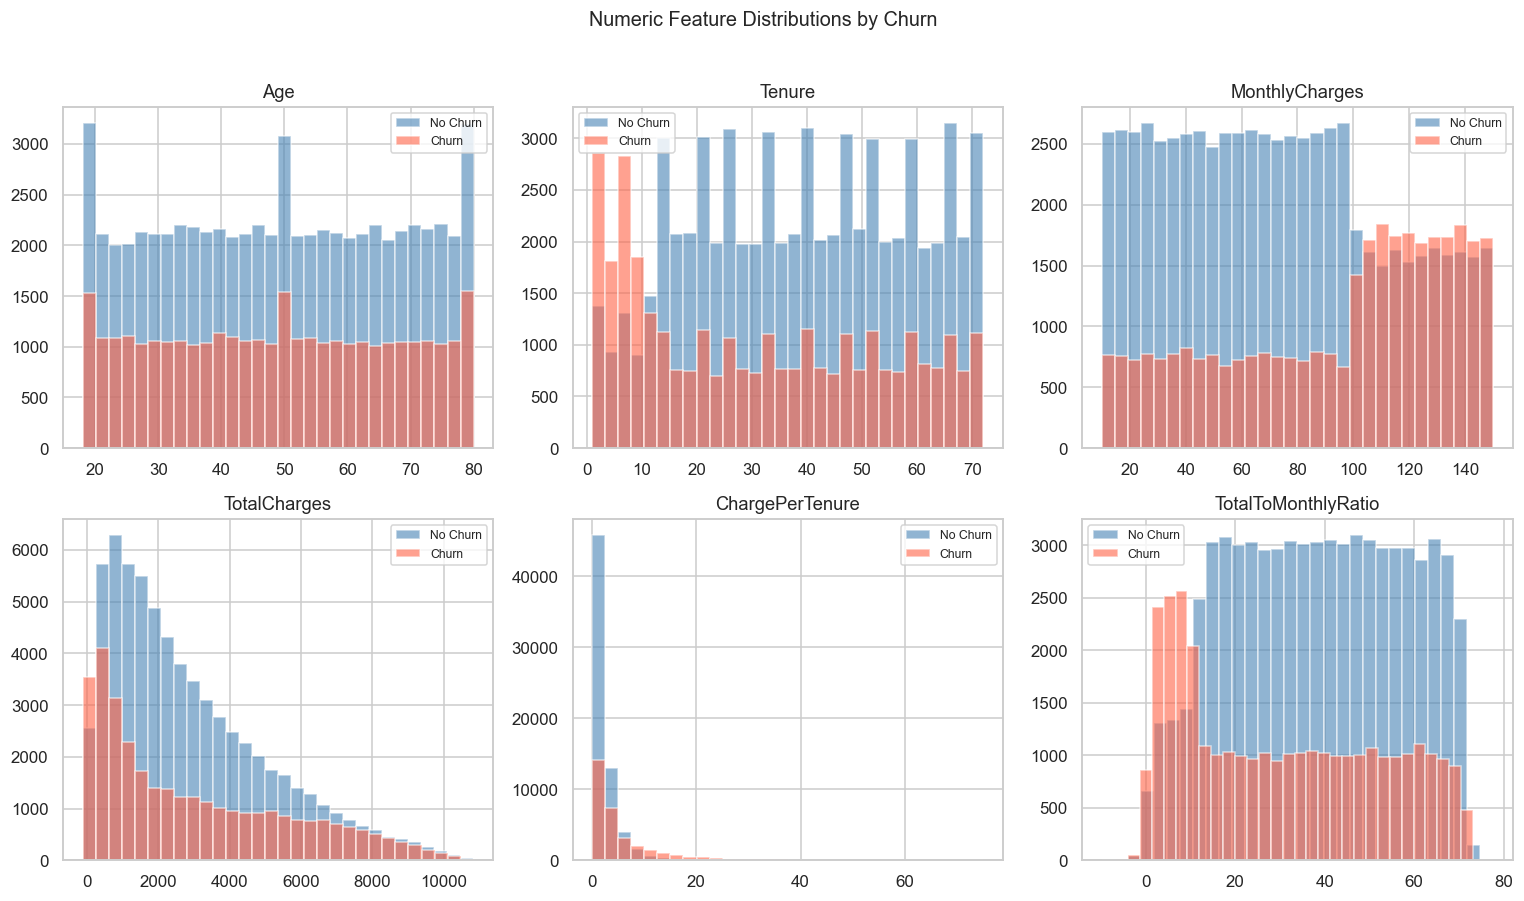

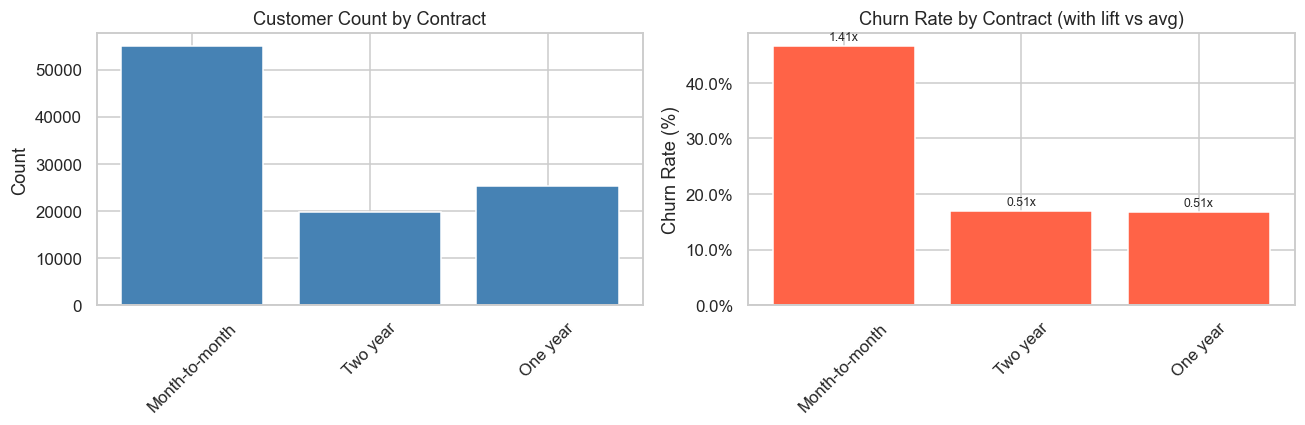

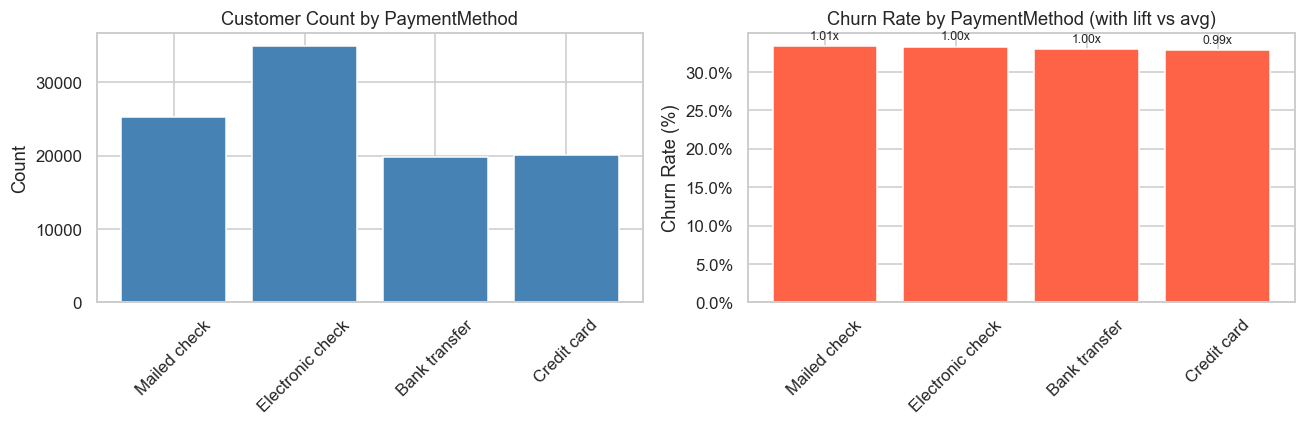

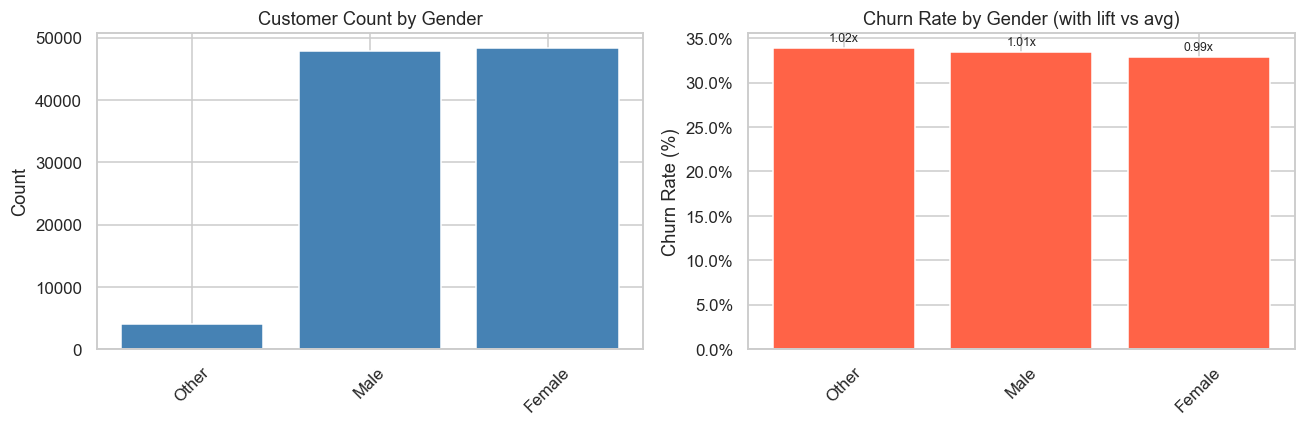

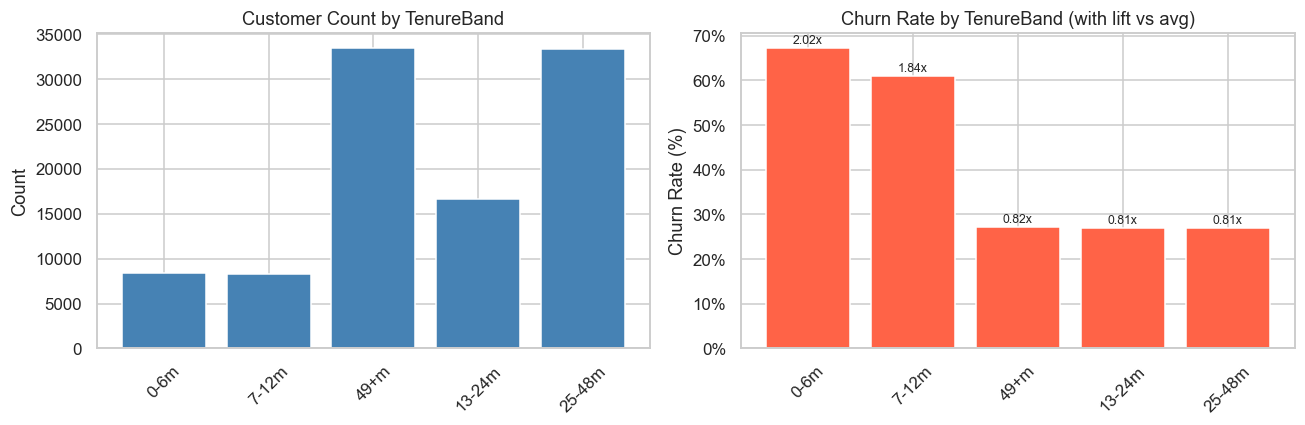

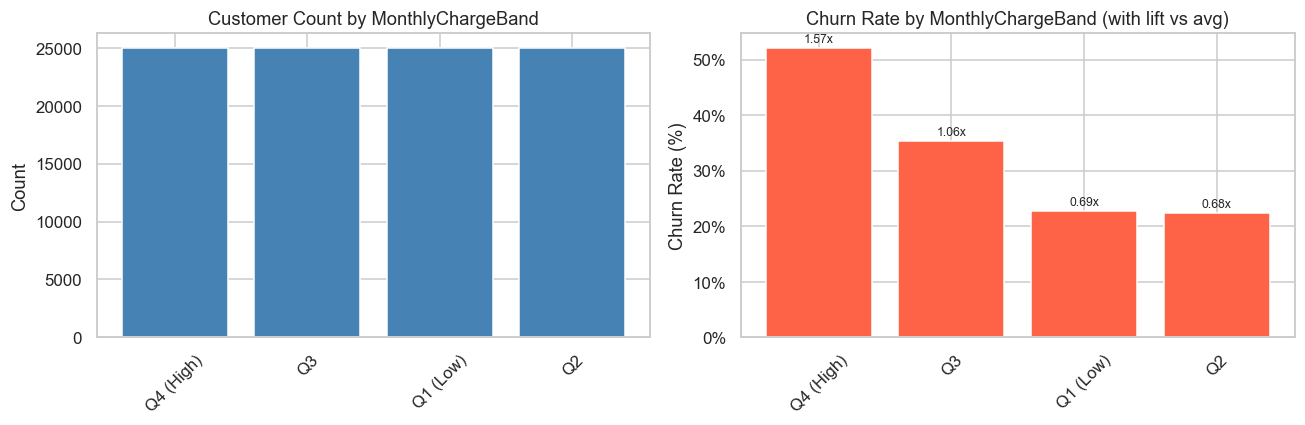

In [8]:
# ============================================================
# CELL 7 — EXPLORATORY DATA ANALYSIS
# ============================================================
print_section("4. EXPLORATORY DATA ANALYSIS")

candidate_group_cols = [
    "ContractType", "Contract", "PaymentMethod", "InternetService",
    "Gender", "SeniorCitizen", "TechSupport", "TenureBand",
    "MonthlyChargeBand", "AgeBand", "PaperlessBilling", "OnlineSecurity"
]
existing_group_cols = [c for c in candidate_group_cols if c in df.columns]

for col in existing_group_cols:
    tbl = churn_rate_table(df, col, TARGET_COL)
    print(f"\n--- Churn by {col} ---")
    print(tbl.to_string())

# Numeric distributions — churn vs non-churn
num_cols = [c for c in df.select_dtypes(include=np.number).columns
            if c != TARGET_COL]

fig, axes = plt.subplots(2, min(3, len(num_cols)), figsize=(14, 8), sharey=False)
axes = axes.flatten()
for i, col in enumerate(num_cols[:6]):
    axes[i].hist(df.loc[df[TARGET_COL] == 0, col].dropna(),
                 bins=30, alpha=0.6, label="No Churn", color="steelblue")
    axes[i].hist(df.loc[df[TARGET_COL] == 1, col].dropna(),
                 bins=30, alpha=0.6, label="Churn", color="tomato")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Numeric Feature Distributions by Churn", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Bar charts for top categorical features
for col in existing_group_cols[:5]:
    summary = churn_rate_table(df, col, TARGET_COL).reset_index()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Volume
    axes[0].bar(summary[col].astype(str), summary["n"], color="steelblue")
    axes[0].set_title(f"Customer Count by {col}")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_ylabel("Count")
    # Churn rate + lift annotation
    bars = axes[1].bar(summary[col].astype(str), summary["churn_rate_pct"],
                       color="tomato")
    for bar, lift in zip(bars, summary["lift_vs_avg"]):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5, f"{lift:.2f}x",
                     ha="center", va="bottom", fontsize=8)
    axes[1].set_title(f"Churn Rate by {col} (with lift vs avg)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_ylabel("Churn Rate (%)")
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    plt.tight_layout()
    plt.show()

## 🔗 Section 8 — Correlation & Multicollinearity Analysis

Before feeding features into models, we need to understand how they relate to each other — not just to the target.

**Pearson Correlation Heatmap:**  
Reveals linear relationships between numeric features. Strong correlations between *predictor* variables (not just with the target) signal potential multicollinearity — where two features tell the model the same story, which can destabilise coefficients in linear models.

**Expected high correlations in telecom data:**
- `Tenure` ↔ `TotalCharges` — customers who've been around longer have paid more in total (obvious mathematical relationship)
- `MonthlyCharges` ↔ `TotalCharges` — if tenure is similar, these move together

**Variance Inflation Factor (VIF):**  
VIF quantifies how much a feature's variance is explained by other features. The rule of thumb:
- VIF < 5 → acceptable
- VIF 5–10 → moderate concern
- VIF > 10 → **high multicollinearity** — consider dropping or combining one of the correlated features

> 💡 **Why it matters for business:** Multicollinearity doesn't hurt predictive accuracy much, but it does distort feature importance — making it look like `TotalCharges` is important when it's really just a proxy for `Tenure`. Clean features = trustworthy interpretations.



  5. CORRELATION & MULTICOLLINEARITY


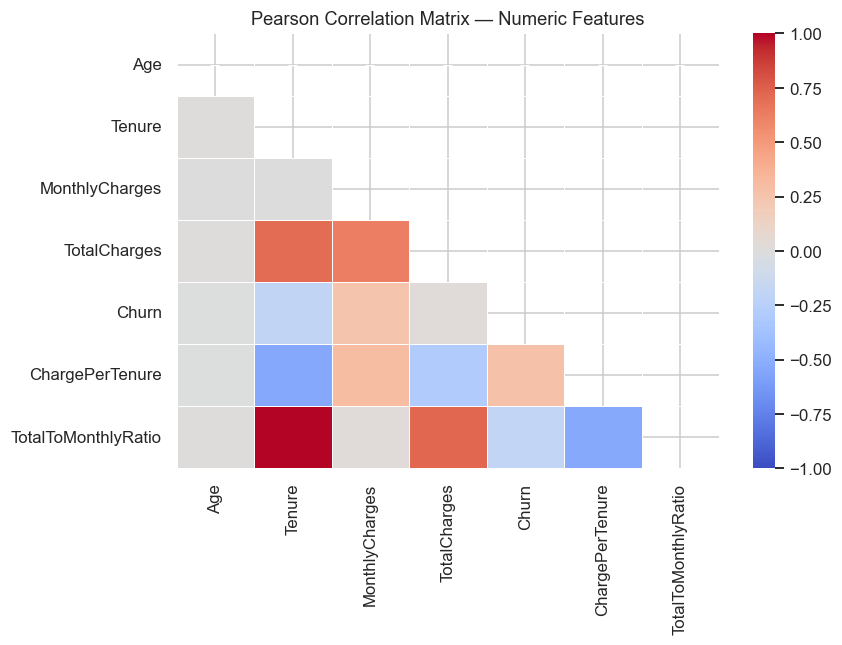


Correlation with churn target (absolute, numeric only):
ChargePerTenure        0.2731
MonthlyCharges         0.2501
Tenure                 0.1909
TotalToMonthlyRatio    0.1862
TotalCharges           0.0239
Age                    0.0059

--- Variance Inflation Factor (VIF) ---
               feature     VIF
6  TotalToMonthlyRatio  257.17
2               Tenure  245.02
0                const   27.16
4         TotalCharges    9.69
3       MonthlyCharges    5.24
5      ChargePerTenure    1.86
1                  Age    1.00

⚠ Features with VIF > 10 (potential multicollinearity):
               feature         VIF
6  TotalToMonthlyRatio  257.168653
2               Tenure  245.015706
0                const   27.157015


In [9]:
# ============================================================
# CELL 8 — CORRELATION & MULTICOLLINEARITY
# ============================================================
print_section("5. CORRELATION & MULTICOLLINEARITY")

# Correlation heatmap (numeric features)
num_df = df.select_dtypes(include=np.number).dropna()

if len(num_df.columns) > 1:
    corr = num_df.corr()
    fig, ax = plt.subplots(figsize=(max(8, len(corr.columns)), max(6, len(corr.columns) - 2)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        linewidths=0.5, ax=ax
    )
    ax.set_title("Pearson Correlation Matrix — Numeric Features")
    plt.tight_layout()
    plt.show()

    # Correlation with target
    target_corr = corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
    print("\nCorrelation with churn target (absolute, numeric only):")
    print(target_corr.round(4).to_string())

# VIF analysis — multicollinearity check
print("\n--- Variance Inflation Factor (VIF) ---")
vif_features = num_df.drop(columns=[TARGET_COL]).dropna()
if len(vif_features.columns) > 1:
    from statsmodels.tools.tools import add_constant
    X_vif = add_constant(vif_features)
    try:
        vif_data = pd.DataFrame({
            "feature": X_vif.columns,
            "VIF": [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])]
        }).sort_values("VIF", ascending=False)
        print(vif_data.round(2).to_string())
        high_vif = vif_data[vif_data.VIF > 10]
        if not high_vif.empty:
            print("\n⚠ Features with VIF > 10 (potential multicollinearity):")
            print(high_vif.to_string())
    except Exception as e:
        print(f"VIF computation error: {e}")
else:
    print("Not enough numeric features for VIF.")

## 📐 Section 9 — Statistical Hypothesis Testing

EDA shows us *what* the data looks like. Statistical tests tell us whether differences are **real or random chance**.

**For categorical features — Chi-square + Cramér's V:**
- The chi-square test answers: "Is the churn rate difference across contract types statistically significant, or could it be sampling noise?"
- **Cramér's V** answers: "How large is that association?" A statistically significant result with V = 0.02 is practically irrelevant; V > 0.3 indicates a meaningful relationship.

**For numeric features — Welch t-test + Mann-Whitney U + Cohen's d:**
- **Welch t-test** — compares means between churners and non-churners (does not assume equal variance)
- **Mann-Whitney U** — non-parametric alternative; more robust when distributions are skewed (which tenure and charges typically are)
- **Cohen's d** — standardised effect size; d > 0.5 is a medium effect, d > 0.8 is large and practically meaningful

> ⚠️ **Important distinction:** With 100K rows, almost *every* test will be statistically significant (p < 0.05) simply because we have so much data. Always focus on **effect size** (Cramér's V, Cohen's d), not just p-values, when deciding which features truly matter.


In [10]:
# ============================================================
# CELL 9 — STATISTICAL TESTING
# ============================================================
print_section("6. STATISTICAL TESTING")

# ---- Chi-square + Cramér's V for categorical features ----
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET_COL]

chi_results = []
for col in cat_cols:
    contingency = pd.crosstab(df[col], df[TARGET_COL])
    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p, dof, _ = chi2_contingency(contingency)
        v = cramers_v(contingency.values)
        chi_results.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": v})

chi_df = pd.DataFrame(chi_results).sort_values("p_value")
print("Chi-square test + Cramér's V (categorical vs churn):")
print(chi_df.round(4).head(20).to_string())

# ---- Mann-Whitney U + Welch t-test for numeric features ----
num_test_results = []
for col in num_cols:
    g0 = df.loc[df[TARGET_COL] == 0, col].dropna()
    g1 = df.loc[df[TARGET_COL] == 1, col].dropna()
    if len(g0) > 5 and len(g1) > 5:
        t_stat, t_p = ttest_ind(g0, g1, equal_var=False)
        u_stat, u_p = mannwhitneyu(g0, g1, alternative="two-sided")
        cohens_d  = (g1.mean() - g0.mean()) / np.sqrt(
            ((len(g0) - 1) * g0.std()**2 + (len(g1) - 1) * g1.std()**2)
            / (len(g0) + len(g1) - 2)
        )
        num_test_results.append({
            "feature": col,
            "mean_no_churn": g0.mean(),
            "mean_churn":    g1.mean(),
            "t_test_p":      t_p,
            "mannwhitney_p": u_p,
            "cohens_d":      cohens_d
        })

num_test_df = pd.DataFrame(num_test_results).sort_values("mannwhitney_p")
print("\nNumeric statistical tests (Welch t, Mann-Whitney, Cohen's d):")
print(num_test_df.round(4).head(20).to_string())

print("\n--- Interpretation ---")
print(
    "Low p-values signal statistically significant differences. "
    "Cramér's V quantifies effect size for categorical variables; "
    "Cohen's d does so for numeric variables. Large effect sizes "
    "are more practically meaningful than statistical significance alone."
)


  6. STATISTICAL TESTING
Chi-square test + Cramér's V (categorical vs churn):
             feature       chi2  p_value  cramers_v
1           Contract  9889.9817   0.0000     0.3145
3         TenureBand  8658.2276   0.0000     0.2942
4  MonthlyChargeBand  6626.6041   0.0000     0.2574
0             Gender     4.0328   0.1331     0.0064
5            AgeBand     3.2035   0.5244     0.0057
2      PaymentMethod     2.0281   0.5666     0.0045

Numeric statistical tests (Welch t, Mann-Whitney, Cohen's d):
               feature  mean_no_churn  mean_churn  t_test_p  mannwhitney_p  cohens_d
1               Tenure        39.3218     30.8898     0.000         0.0000   -0.4132
2       MonthlyCharges        72.8458     94.3553     0.000         0.0000    0.5486
4      ChargePerTenure         2.9129      7.0819     0.000         0.0000    0.6031
5  TotalToMonthlyRatio        38.5222     30.4340     0.000         0.0000   -0.4025
3         TotalCharges      2886.0194   3007.0696     0.000         0

## ⏳ Section 10 — Survival Analysis (Kaplan-Meier)

Standard churn prediction asks *will this customer churn?* Survival analysis asks *when will they churn?*

**The Kaplan-Meier curve** shows the probability of a customer *still being active* at each tenure month. A curve that drops sharply in the first 6 months tells a completely different story than one that erodes gradually — and requires a completely different retention intervention.

**Log-rank test:**  
Tests whether survival curves for different groups (e.g., contract types) are statistically different from each other. A very low p-value confirms that the groups have genuinely different churn trajectories — not just different average rates.

**What to look for:**
- **Steep early drop:** High early-life churn — onboarding and first-90-days experience is broken
- **Cliff at 12 months:** Churn spikes when annual contracts expire — the retention team needs to engage 60–90 days *before* contract renewal
- **Wide confidence intervals:** Uncertainty is high in this segment — possibly small sample size

> 💡 **Business application:** Kaplan-Meier curves are powerful for designing intervention timing. If you know 40% of at-risk customers churn in months 3–4, you target them in month 2 — not after the fact.


In [11]:
# ============================================================
# CELL 10 — SURVIVAL ANALYSIS (Kaplan-Meier)
# ============================================================
print_section("7. SURVIVAL ANALYSIS — Kaplan-Meier")

if not lifelines_available:
    print("lifelines not installed. Install with: pip install lifelines")
elif "Tenure" not in df.columns:
    print("'Tenure' column not found. Survival analysis skipped.")
else:
    T = df["Tenure"].fillna(df["Tenure"].median())
    E = df[TARGET_COL].fillna(0).astype(int)

    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10, 6))

    # Overall curve
    kmf.fit(T, event_observed=E, label="Overall")
    kmf.plot_survival_function(ci_show=True, at_risk_counts=False)

    # Stratified by a key segment
    segment_col = next(
        (c for c in ["Contract", "ContractType"] if c in df.columns), None
    )
    if segment_col:
        for grp in df[segment_col].dropna().unique():
            mask = df[segment_col] == grp
            kmf.fit(T[mask], event_observed=E[mask], label=str(grp))
            kmf.plot_survival_function(ci_show=False)

        # Log-rank test across groups
        groups = df[segment_col].dropna().unique()
        if len(groups) == 2:
            mask0 = df[segment_col] == groups[0]
            mask1 = df[segment_col] == groups[1]
            result = logrank_test(T[mask0], T[mask1], E[mask0], E[mask1])
            print(f"Log-rank p-value ({groups[0]} vs {groups[1]}): {result.p_value:.4f}")

    plt.xlabel("Tenure (months)")
    plt.ylabel("Probability of NOT Churning")
    plt.title("Kaplan-Meier Survival Curves")
    plt.tight_layout()
    plt.show()
    print(
        "The KM curve shows how quickly different customer segments "
        "leave the service. A steeper early drop indicates high early-life churn."
    )


  7. SURVIVAL ANALYSIS — Kaplan-Meier
lifelines not installed. Install with: pip install lifelines


## ✂️ Section 11 — Train / Test Split

We split the data into a training set (80%) and a held-out test set (20%) *before* any model training begins.

**Why stratified splitting?**  
`stratify=y` ensures both splits have the same churn rate. Without this, random chance could put most churners in one split — producing artificially inflated or deflated metrics.

**Why a fixed `random_state`?**  
Reproducibility. Anyone re-running this notebook gets identical splits, enabling fair comparison and audit trail.

**The critical rule:** The test set is *sacred*. It must never be used to make any modelling decision (hyperparameter selection, feature engineering choices, threshold picking). Using test data to guide decisions makes the final evaluation optimistic and misleading — a form of subtle data leakage.

> 💡 For production deployment, a **time-based split** (train on months 1–18, test on months 19–24) is more representative — it simulates the actual deployment scenario where you train on the past and predict the future.


In [12]:
# ============================================================
# CELL 11 — TRAIN/TEST SPLIT
# ============================================================
print_section("8. TRAIN / TEST SPLIT")

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Test  churn rate: {y_test.mean():.4f}")


  8. TRAIN / TEST SPLIT
Train: (80000, 12)  |  Test: (20000, 12)
Train churn rate: 0.3314
Test  churn rate: 0.3315


## 🔄 Section 12 — Preprocessing Pipelines

Rather than preprocessing data directly, we build **scikit-learn Pipeline objects** that bundle transformation logic with the model.

**Why pipelines instead of manual preprocessing?**
1. **No data leakage** — the scaler's mean/std and encoder's categories are fitted only on training data, then *applied* to test data. Manual preprocessing often accidentally fits on the full dataset.
2. **Production-ready** — the entire pipeline (preprocessor + model) can be serialised with `pickle` or `joblib` and deployed as a single object
3. **Cross-validation safe** — when used inside `cross_validate()`, the pipeline refits preprocessing on each fold, preventing look-ahead bias

**Numeric pipeline:** Median imputation (robust to outliers) → Standard scaling (mean=0, std=1)  
**Categorical pipeline:** Mode imputation (most frequent category) → One-hot encoding  

> ⚠️ `handle_unknown='ignore'` in OneHotEncoder is important for production: if a new category appears in live data that wasn't in training (e.g., a new payment method), the encoder silently assigns zeros rather than crashing.


In [13]:
# ============================================================
# CELL 12 — PREPROCESSING PIPELINES
# ============================================================
print_section("9. PREPROCESSING PIPELINES")

numeric_features     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print(f"Numeric features  ({len(numeric_features)}):     {numeric_features[:8]} ...")
print(f"Categorical features ({len(categorical_features)}): {categorical_features[:8]} ...")


  9. PREPROCESSING PIPELINES
Numeric features  (6):     ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'ChargePerTenure', 'TotalToMonthlyRatio'] ...
Categorical features (6): ['Gender', 'Contract', 'PaymentMethod', 'TenureBand', 'MonthlyChargeBand', 'AgeBand'] ...


## ⚖️ Section 13 — Handling Class Imbalance

In most telecom datasets, 70–85% of customers do *not* churn. Training a model on imbalanced data without compensation produces a model that is biased toward predicting the majority class — high accuracy, but missing nearly all actual churners.

**Two strategies compared:**

**1. `class_weight='balanced'`**  
Penalises the model more heavily for misclassifying the minority class (churners). Mathematically: each churner is weighted as `n_samples / (2 × n_churn)`, making them more "expensive" to misclassify. Simple, no data modification needed.

**2. SMOTE (Synthetic Minority Over-sampling Technique)**  
Generates *synthetic* churner examples by interpolating between real minority-class data points. This creates a balanced training set with artificially diverse churner profiles.

**Metric of choice: PR-AUC (Precision-Recall AUC)**  
On imbalanced problems, ROC-AUC can be misleadingly optimistic. PR-AUC is a stricter metric — it focuses on how well we identify the rare positive class (churners) and is more relevant when the cost of false negatives is high.

> 💡 **Business translation:** A false negative (missed churner) costs you a full customer. A false positive (wrongly flagged loyal customer) costs you the price of a retention offer. In most scenarios, false negatives are 3–10× more expensive — which should guide threshold decisions later.


In [14]:
# ============================================================
# CELL 13 — CLASS IMBALANCE: class_weight vs SMOTE
# ============================================================
print_section("10. CLASS IMBALANCE HANDLING")

# Baseline Logistic Regression with class_weight='balanced'
lr_cw = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 random_state=RANDOM_STATE))
])

cv_cw = cross_validate(
    lr_cw, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
    n_jobs=-1
)
print(f"LogReg class_weight balanced — ROC-AUC: {cv_cw['test_roc_auc'].mean():.4f} "
      f"| PR-AUC: {cv_cw['test_pr_auc'].mean():.4f}")

# SMOTE comparison
if smote_available:
    lr_smote = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])
    cv_sm = cross_validate(
        lr_smote, X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision"},
        n_jobs=-1
    )
    print(f"LogReg + SMOTE            — ROC-AUC: {cv_sm['test_roc_auc'].mean():.4f} "
          f"| PR-AUC: {cv_sm['test_pr_auc'].mean():.4f}")
    print(
        "\nNote: SMOTE can improve recall on minority class but may inflate ROC-AUC if "
        "evaluated on oversampled folds. Always validate on original test distribution."
    )
else:
    print("SMOTE skipped (imbalanced-learn not installed).")


  10. CLASS IMBALANCE HANDLING
LogReg class_weight balanced — ROC-AUC: 0.7980 | PR-AUC: 0.6609
LogReg + SMOTE            — ROC-AUC: 0.7976 | PR-AUC: 0.6600

Note: SMOTE can improve recall on minority class but may inflate ROC-AUC if evaluated on oversampled folds. Always validate on original test distribution.


## 🏆 Section 14 — Model Comparison via Cross-Validation

We evaluate five model families using **5-fold stratified cross-validation**, which gives us 5 independent estimates of each model's performance on unseen data — far more reliable than a single train/test split.

**Model candidates:**

| Model | Strengths | Weaknesses |
|---|---|---|
| Dummy Classifier | Establishes the "do-nothing" baseline — any real model must beat this | No actual learning |
| Logistic Regression | Fast, highly interpretable, great baseline | Assumes linear decision boundary |
| Random Forest | Handles non-linearity, robust to outliers, provides feature importances | Slower to train, less interpretable than LogReg |
| Gradient Boosting | Often best accuracy, captures complex interactions | Prone to overfitting without careful tuning |
| XGBoost | State-of-the-art on tabular data; regularisation built-in | Requires more hyperparameter tuning |

**Metrics tracked:**
- **ROC-AUC** — overall discriminative ability across all thresholds
- **PR-AUC** — precision-recall balance, more relevant for imbalanced data
- **F1** — harmonic mean of precision and recall at the default threshold
- **Precision / Recall** — broken out separately to understand the tradeoff

> 💡 **Why cross-validation matters:** A single train/test split can be lucky or unlucky. Cross-validation averages over 5 different random splits of the training data, giving a more stable and trustworthy performance estimate before we ever touch the held-out test set.



  11. CROSS-VALIDATION MODEL COMPARISON


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precis

           model  roc_auc  roc_auc_std  pr_auc     f1  precision  recall
GradientBoosting   0.8069       0.0036  0.6781 0.6067     0.6700  0.5544
         XGBoost   0.8050       0.0042  0.6762 0.6045     0.6678  0.5521
    RandomForest   0.8018       0.0036  0.6679 0.6132     0.5957  0.6319
          LogReg   0.7980       0.0046  0.6609 0.6108     0.5787  0.6468
Dummy (baseline)   0.5000       0.0000  0.3314 0.0000     0.0000  0.0000


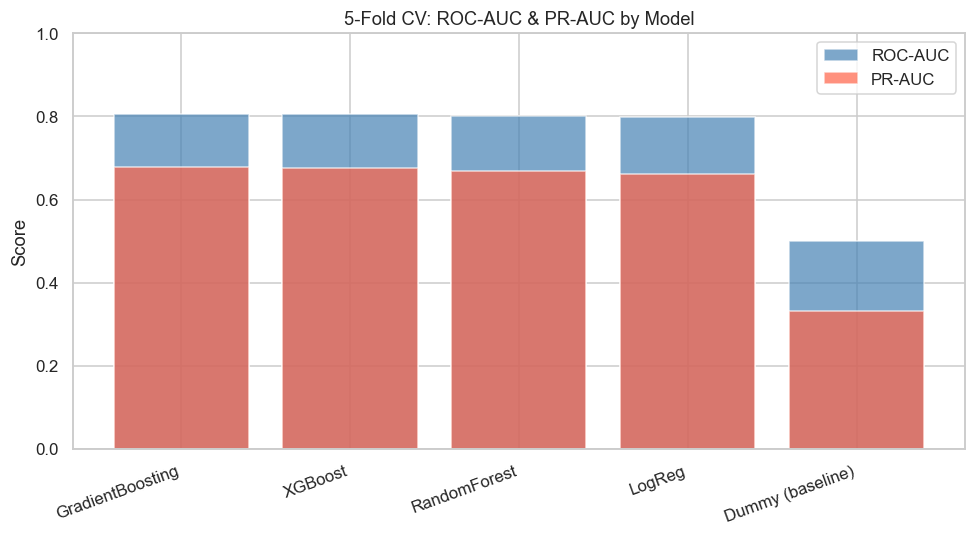


Best model by ROC-AUC: GradientBoosting


In [15]:
# ============================================================
# CELL 14 — MODEL CANDIDATES & CROSS-VALIDATION
# ============================================================
print_section("11. CROSS-VALIDATION MODEL COMPARISON")

models = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced",
                                  random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, min_samples_split=10, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}
if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=RANDOM_STATE
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc":  "average_precision",
    "f1":      "f1",
    "precision": "precision",
    "recall":    "recall"
}

cv_results = []
for model_name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)
    cv_results.append({
        "model":          model_name,
        "roc_auc":        scores["test_roc_auc"].mean(),
        "roc_auc_std":    scores["test_roc_auc"].std(),
        "pr_auc":         scores["test_pr_auc"].mean(),
        "f1":             scores["test_f1"].mean(),
        "precision":      scores["test_precision"].mean(),
        "recall":         scores["test_recall"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("roc_auc", ascending=False)
print(cv_results_df.round(4).to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(cv_results_df))
ax.bar(x, cv_results_df["roc_auc"], alpha=0.7, label="ROC-AUC", color="steelblue")
ax.bar(x, cv_results_df["pr_auc"],  alpha=0.7, label="PR-AUC",  color="tomato",
       bottom=0)
ax.set_xticks(x)
ax.set_xticklabels(cv_results_df["model"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("5-Fold CV: ROC-AUC & PR-AUC by Model")
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

best_model_name = cv_results_df.iloc[0]["model"]
best_model = models[best_model_name]
print(f"\nBest model by ROC-AUC: {best_model_name}")

## 🎛️ Section 15 — Hyperparameter Tuning

The best model from cross-validation is now fine-tuned using **GridSearchCV** — an exhaustive search over a defined parameter grid.

**What we're tuning:**
- `n_estimators` — more trees generally improve performance but increase training time; diminishing returns after ~300
- `max_depth` — controls tree depth; deeper trees can fit training data better but risk overfitting; `None` means unlimited depth
- `learning_rate` (boosting models) — smaller rates with more trees often generalise better; the classic "slow learning" principle
- `min_samples_leaf` — minimum samples at each leaf node; acts as regularisation, preventing the model from memorising noise

**3-fold CV inside GridSearch** (vs. 5-fold for model selection) balances search thoroughness with compute time.

> 💡 **Practical consideration:** GridSearch with large grids and slow models can take hours. In production, **RandomizedSearchCV** is often preferred — it samples parameter combinations randomly and typically finds near-optimal settings 10–20× faster than exhaustive grid search.


In [16]:
# ============================================================
# CELL 15 — HYPERPARAMETER TUNING
# ============================================================
print_section("12. HYPERPARAMETER TUNING")

param_grids = {
    "RandomForest": {
        "model__n_estimators": [200, 300],
        "model__max_depth":    [None, 10, 20],
        "model__min_samples_leaf": [3, 5]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth":     [3, 4]
    },
    "XGBoost": {
        "model__n_estimators":  [100, 200],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth":     [3, 5]
    }
}

final_model = None
if best_model_name in param_grids:
    print(f"Tuning {best_model_name}...")
    pipe = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
    grid = GridSearchCV(
        pipe, param_grids[best_model_name],
        scoring="roc_auc", cv=3, n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    final_model = grid.best_estimator_
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")
else:
    final_model = Pipeline([("preprocessor", preprocessor), ("model", best_model)])
    final_model.fit(X_train, y_train)
    print(f"No param grid for {best_model_name}; fitting with defaults.")

print("Final model ready.")


  12. HYPERPARAMETER TUNING
Tuning GradientBoosting...
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.8076
Final model ready.


## 📋 Section 16 — Test Set Evaluation

After all training and tuning decisions are locked in, we evaluate the final model on the **completely unseen test set** exactly once. This is our honest estimate of real-world performance.

**Metrics reported:**

| Metric | What it measures | Good range |
|---|---|---|
| **ROC-AUC** | Probability that the model ranks a random churner above a random non-churner | > 0.80 is good; > 0.90 is excellent |
| **PR-AUC** | Area under the precision-recall curve; critical for imbalanced data | Depends on churn rate; should be >> than the baseline (churn rate itself) |
| **Brier Score** | Mean squared error of predicted probabilities; measures calibration | < 0.10 is excellent; lower is better |

**The confusion matrix at threshold 0.50:**  
This reveals the raw counts of true positives (correctly flagged churners), false negatives (missed churners), and false positives (wrongly flagged loyal customers). At this stage we're just recording performance — threshold optimisation comes next.

> ⚠️ **Never use test set results to make modelling decisions.** If you adjust the model based on these results and re-test, you have implicitly trained on the test set, and your reported metrics will be optimistic.



  13. TEST SET EVALUATION
ROC-AUC : 0.8051
PR-AUC  : 0.6729
Brier   : 0.1584  (lower = better calibrated)

Classification report @ threshold 0.50:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83     13371
           1       0.67      0.56      0.61      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.71      0.72     20000
weighted avg       0.76      0.76      0.76     20000



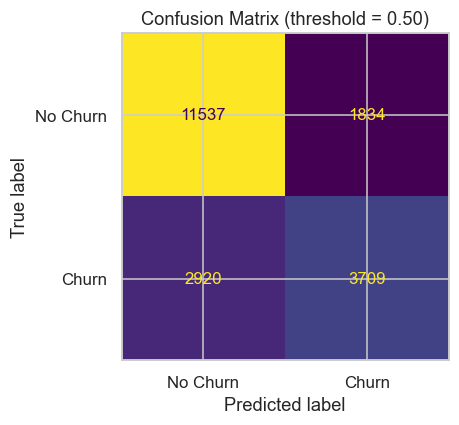

In [17]:
# ============================================================
# CELL 16 — TEST SET EVALUATION
# ============================================================
print_section("13. TEST SET EVALUATION")

y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.50).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
brier   = brier_score_loss(y_test, y_proba)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print(f"Brier   : {brier:.4f}  (lower = better calibrated)")
print("\nClassification report @ threshold 0.50:")
print(classification_report(y_test, y_pred_default))

# Confusion matrix visual
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=["No Churn", "Churn"],
    colorbar=False, ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.50)")
plt.tight_layout()
plt.show()

## 🎯 Section 17 — Classification Threshold Optimisation

The default probability threshold of 0.50 is almost never optimal for business applications. Here we find the threshold that maximises F1 score — the harmonic mean of precision and recall.

**The precision-recall tradeoff:**
- **Lowering the threshold** → catch more churners (higher recall), but also flag more loyal customers as at-risk (lower precision). More intervention budget spent, more disruptions to loyal customers.
- **Raising the threshold** → very confident before flagging a churner (higher precision), but miss more actual churners (lower recall). More focused campaigns, but more missed opportunities.

**Which matters more depends on business context:**
- If retention offers are **expensive** (e.g., $50 discount calls) → favour higher precision
- If retention offers are **cheap** (e.g., automated email) and churners are **high-value** → favour higher recall

**Why F1 as the tiebreaker?**  
F1 gives equal weight to precision and recall — a reasonable default when we don't have a precise cost model for false positives vs. false negatives. The revenue simulation in later cells provides that cost model and allows further refinement.



  14. THRESHOLD OPTIMISATION
Selected threshold (best F1): 0.35

Classification report @ optimised threshold:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82     13371
           1       0.63      0.62      0.62      6629

    accuracy                           0.76     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.75      0.76      0.75     20000



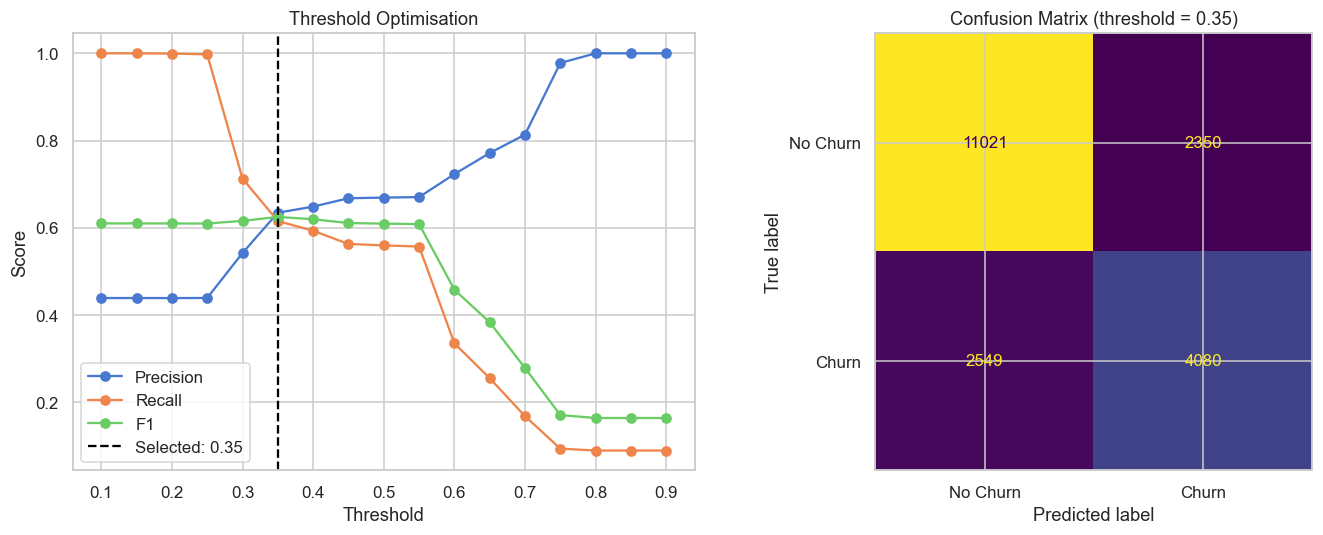

In [18]:
# ============================================================
# CELL 17 — THRESHOLD OPTIMISATION
# ============================================================
print_section("14. THRESHOLD OPTIMISATION")

threshold_metrics = []
for t in np.arange(0.10, 0.91, 0.05):
    preds = (y_proba >= t).astype(int)
    threshold_metrics.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall":    recall_score(y_test, preds, zero_division=0),
        "f1":        f1_score(y_test, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_metrics)
best_threshold = float(
    threshold_df.sort_values(["f1", "recall"], ascending=False).iloc[0]["threshold"]
)
print(f"Selected threshold (best F1): {best_threshold}")

y_pred_best = (y_proba >= best_threshold).astype(int)
print("\nClassification report @ optimised threshold:")
print(classification_report(y_test, y_pred_best))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Threshold vs metric
axes[0].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
axes[0].plot(threshold_df["threshold"], threshold_df["recall"],    marker="o", label="Recall")
axes[0].plot(threshold_df["threshold"], threshold_df["f1"],        marker="o", label="F1")
axes[0].axvline(best_threshold, linestyle="--", color="black", label=f"Selected: {best_threshold}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Threshold Optimisation")
axes[0].legend()

# Confusion matrix at best threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["No Churn", "Churn"],
    colorbar=False, ax=axes[1]
)
axes[1].set_title(f"Confusion Matrix (threshold = {best_threshold})")
plt.tight_layout()
plt.show()

## 📉 Section 18 — ROC & Precision-Recall Curves

These two curves provide the full picture of model performance — independent of any single threshold decision.

**ROC Curve (Receiver Operating Characteristic):**  
Plots True Positive Rate vs. False Positive Rate at every possible threshold. The **AUC (Area Under Curve)** summarises this into a single number: probability that the model ranks a random churner above a random non-churner. A random classifier scores 0.50; a perfect classifier scores 1.00.

**Precision-Recall Curve:**  
More informative than ROC for **imbalanced datasets**. The horizontal dashed baseline represents a random classifier (equal to the churn rate). Our model must significantly outperform this baseline to be useful.

**Which curve to prioritise?**  
- ROC-AUC: good for comparing models against each other
- PR-AUC: better for evaluating real-world business usefulness when churners are the rare class

> 💡 **Stakeholder communication tip:** ROC curves are intuitive to technical audiences. For business stakeholders, the **cumulative gains curve** (later in this notebook) is often easier to explain: "if we contact the top 20% of customers by risk score, we reach X% of all churners."



  15. ROC AND PRECISION-RECALL CURVES


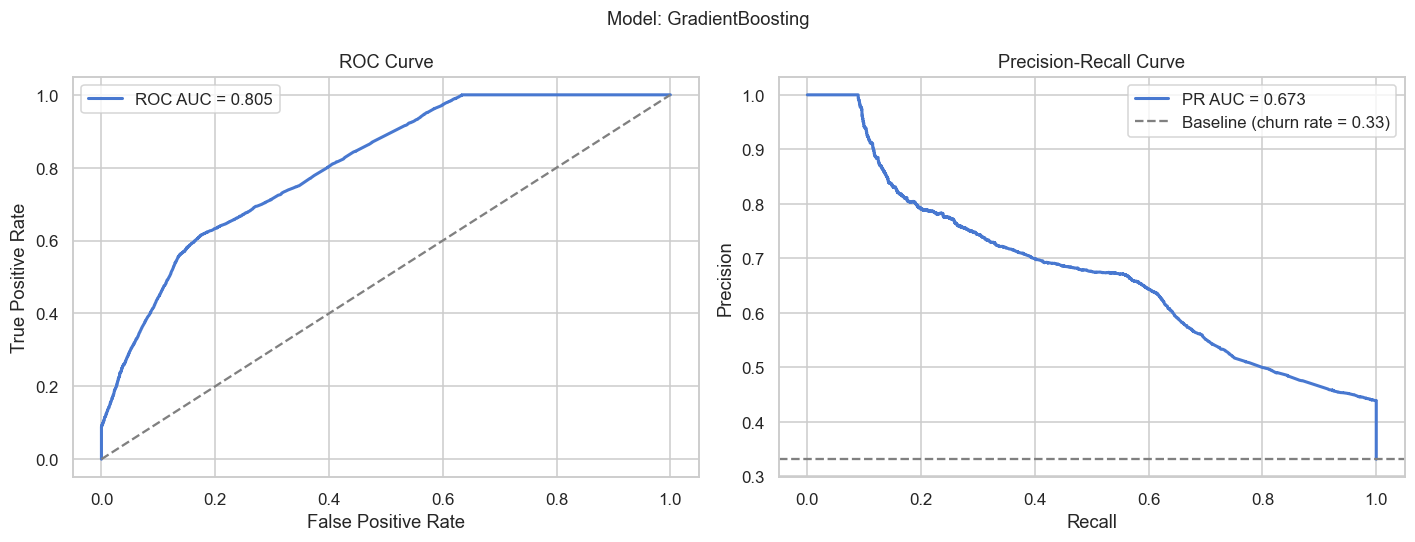

In [19]:
# ============================================================
# CELL 18 — ROC & PRECISION-RECALL CURVES
# ============================================================
print_section("15. ROC AND PRECISION-RECALL CURVES")

fpr, tpr, _ = roc_curve(y_test, y_proba)
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
baseline_precision = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall
axes[1].plot(recalls, precisions, lw=2, label=f"PR AUC = {pr_auc:.3f}")
axes[1].axhline(baseline_precision, linestyle="--", color="grey",
                label=f"Baseline (churn rate = {baseline_precision:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.suptitle(f"Model: {best_model_name}", fontsize=12)
plt.tight_layout()
plt.show()

## 📏 Section 19 — Probability Calibration

A model with AUC of 0.88 can still produce poorly calibrated probabilities — e.g., when it predicts "0.80 churn probability", it could be that only 40% of such customers actually churn in reality.

**Why calibration matters for business:**  
In the revenue-at-risk calculations later, we multiply each customer's churn probability by their monthly spend. If probabilities are inflated by 2×, our revenue-at-risk estimates will be wrong by 2× — leading to budget misallocation.

**The Reliability Diagram:**  
Plots predicted probabilities (x-axis) against the actual observed churn rate within that probability bin (y-axis). A perfectly calibrated model follows the diagonal. Curves above the diagonal mean the model is **underconfident** (predicting 0.3 when 0.5 actually churn). Curves below mean **overconfident**.

**The Brier Score:**  
Mean squared error between predicted probabilities and actual outcomes (0 or 1). Ranges from 0 (perfect) to 1 (worst). A Brier score < 0.10 is considered excellent for churn problems.

**If calibration is poor:**  
Apply `CalibratedClassifierCV` with `method='sigmoid'` (Platt scaling) or `method='isotonic'` after training. Tree-based models (RF, XGBoost) typically need calibration; logistic regression is naturally well-calibrated.



  16. CALIBRATION ANALYSIS


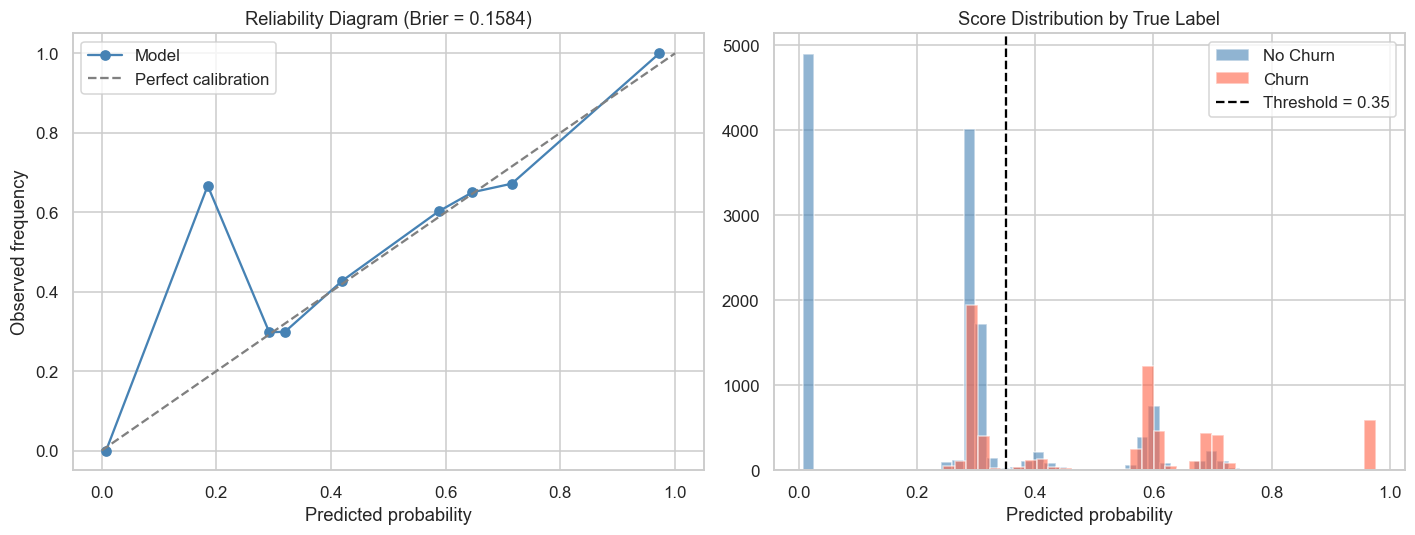

A well-calibrated model is essential when probability scores are used directly for revenue-at-risk estimation. If calibration is poor, apply Platt scaling (CalibratedClassifierCV with 'sigmoid') or isotonic regression.


In [20]:
# ============================================================
# CELL 19 — CALIBRATION ANALYSIS
# ============================================================
print_section("16. CALIBRATION ANALYSIS")

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability diagram
axes[0].plot(prob_pred, prob_true, marker="o", label="Model", color="steelblue")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Observed frequency")
axes[0].set_title(f"Reliability Diagram (Brier = {brier:.4f})")
axes[0].legend()

# Probability distribution
axes[1].hist(y_proba[y_test == 0], bins=40, alpha=0.6, label="No Churn", color="steelblue")
axes[1].hist(y_proba[y_test == 1], bins=40, alpha=0.6, label="Churn",    color="tomato")
axes[1].axvline(best_threshold, linestyle="--", color="black",
                label=f"Threshold = {best_threshold}")
axes[1].set_xlabel("Predicted probability")
axes[1].set_title("Score Distribution by True Label")
axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "A well-calibrated model is essential when probability scores are used directly "
    "for revenue-at-risk estimation. If calibration is poor, apply Platt scaling "
    "(CalibratedClassifierCV with 'sigmoid') or isotonic regression."
)

## 🔎 Section 20 — Feature Importance & SHAP Interpretability

Knowing *that* the model works is not enough — we need to know *why* it makes specific predictions. This is especially critical for regulated industries and for translating model outputs into actionable strategy.

**Two levels of interpretability:**

**1. Global Feature Importance (aggregate)**  
Shows which features the model relies on most overall. For tree models, this is measured by how much each feature reduces impurity across all splits. For logistic regression, it's the absolute coefficient value.

**2. SHAP Values (per-prediction)**  
SHAP (SHapley Additive exPlanations) attributes each prediction to individual features using game theory. Unlike aggregate importance, SHAP shows:
- The *direction* of each feature's effect (e.g., "long tenure *reduces* churn probability by 0.12")
- The *magnitude* for each individual customer — enabling personalised explanations

**SHAP Summary Plot interpretation:**
- Features are sorted by total impact (top = most important)
- Each dot = one customer; color = feature value (red = high, blue = low)
- Position on x-axis = SHAP value (right = increases churn probability)

> 💡 **Business application:** SHAP values allow a retention agent to see exactly *why* a customer was flagged — "this customer has a month-to-month contract (+0.18), no tech support (+0.09), and high monthly charges (+0.07)" — enabling targeted, personalised conversations rather than generic offers.



  17. FEATURE IMPORTANCE & INTERPRETABILITY


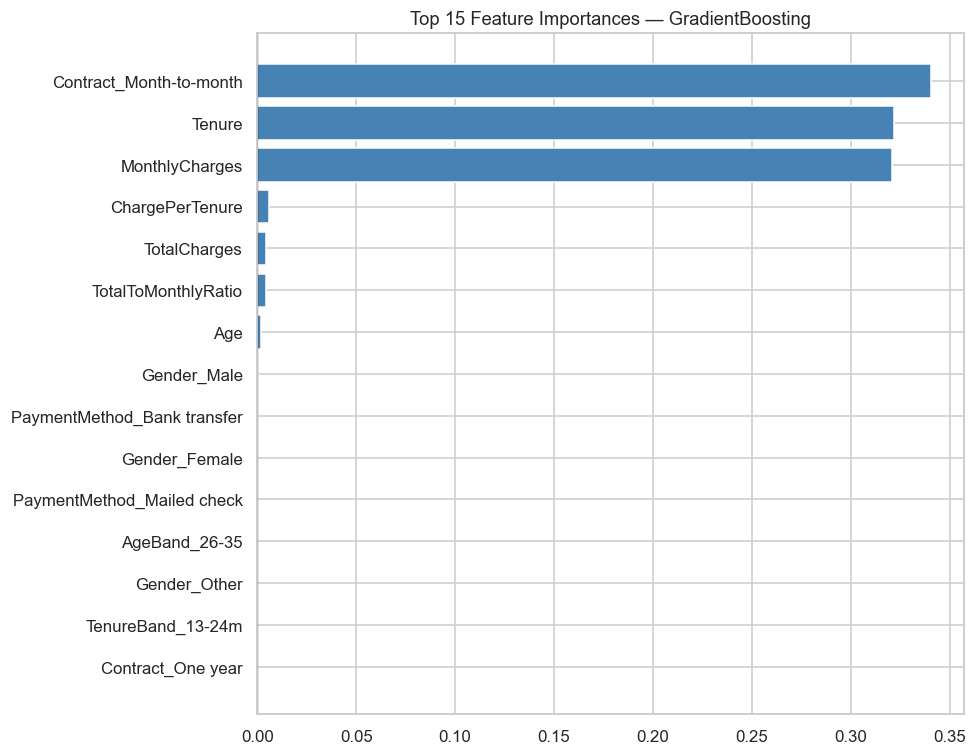

                        feature  importance
9       Contract_Month-to-month     0.34037
1                        Tenure     0.32173
2                MonthlyCharges     0.32091
4               ChargePerTenure     0.00574
3                  TotalCharges     0.00423
5           TotalToMonthlyRatio     0.00419
0                           Age     0.00196
7                   Gender_Male     0.00017
12  PaymentMethod_Bank transfer     0.00014
6                 Gender_Female     0.00011
15   PaymentMethod_Mailed check     0.00008
25                AgeBand_26-35     0.00007
8                  Gender_Other     0.00006
17            TenureBand_13-24m     0.00006
10            Contract_One year     0.00005
22         MonthlyChargeBand_Q2     0.00003
29                 AgeBand_<=25     0.00003
13    PaymentMethod_Credit card     0.00002
11            Contract_Two year     0.00002
26                AgeBand_36-50     0.00001
SHAP not available or model type not supported; see native importances above

In [21]:
# ============================================================
# CELL 20 — FEATURE IMPORTANCE & SHAP
# ============================================================
print_section("17. FEATURE IMPORTANCE & INTERPRETABILITY")

# Extract feature names after OHE
try:
    ohe = final_model.named_steps["preprocessor"] \
                      .named_transformers_["cat"] \
                      .named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
except Exception:
    cat_feature_names = []
all_feature_names = numeric_features + cat_feature_names

model_step = final_model.named_steps["model"]
feature_importance_df = None

if hasattr(model_step, "coef_"):
    feature_importance_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": model_step.coef_[0]
    }).sort_values("importance", ascending=False)

elif hasattr(model_step, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": model_step.feature_importances_
    }).sort_values("importance", ascending=False)

if feature_importance_df is not None:
    top15 = feature_importance_df.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ["tomato" if v < 0 else "steelblue" for v in top15["importance"]]
    ax.barh(top15["feature"], top15["importance"], color=colors)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()
    print(feature_importance_df.head(20).round(5).to_string())

# SHAP
if shap_available and hasattr(model_step, "feature_importances_"):
    print("\nGenerating SHAP values (TreeExplainer)...")
    X_test_transformed = final_model.named_steps["preprocessor"].transform(X_test)
    explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_test_transformed)
    # For binary classification pick the positive class
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(
        sv, X_test_transformed,
        feature_names=all_feature_names,
        max_display=15, show=True
    )
elif shap_available and hasattr(model_step, "coef_"):
    print("\nGenerating SHAP values (LinearExplainer)...")
    X_test_transformed = final_model.named_steps["preprocessor"].transform(X_test)
    masker = shap.maskers.Independent(X_test_transformed, max_samples=200)
    explainer = shap.LinearExplainer(model_step, masker=masker)
    shap_values = explainer.shap_values(X_test_transformed)
    shap.summary_plot(
        shap_values, X_test_transformed,
        feature_names=all_feature_names,
        max_display=15, show=True
    )
else:
    print("SHAP not available or model type not supported; see native importances above.")

## 🔬 Section 21 — Error Analysis

Understanding *where* the model fails is as important as knowing overall accuracy. This analysis profiles the customers we systematically get wrong.

**Error types and their business cost:**

| Error Type | Description | Business Impact |
|---|---|---|
| **False Negative (FN)** | Actual churner predicted as loyal | Customer lost — no intervention, full revenue lost |
| **False Positive (FP)** | Loyal customer flagged as churner | Wasted campaign spend; potential customer annoyance from unsolicited offers |

**Why segment-level error analysis?**  
The model may perform well on average but fail catastrophically for specific high-value segments. For example:
- If the model misses 60% of churners on **2-year contracts** who are actually deciding to leave — that's a high-value FN problem
- If the model over-flags **senior citizens** with false positives — we're wasting budget on a segment that needs more targeted, manual outreach

**False Negative profile:**  
Customers the model misses tend to have *lower predicted probabilities* — they're "quiet churners" who don't exhibit the obvious warning signs. Examining their characteristics reveals blind spots in our feature set and may suggest new data sources to collect.


In [22]:
# ============================================================
# CELL 21 — ERROR ANALYSIS
# ============================================================
print_section("18. ERROR ANALYSIS")

test_results = X_test.copy()
test_results["actual_churn"]     = y_test.values
test_results["predicted_proba"]  = y_proba
test_results["predicted_label"]  = y_pred_best

conditions = [
    (test_results["actual_churn"] == 1) & (test_results["predicted_label"] == 0),
    (test_results["actual_churn"] == 0) & (test_results["predicted_label"] == 1)
]
choices    = ["false_negative", "false_positive"]
test_results["error_type"] = np.select(conditions, choices, default="correct")

print("Error counts:")
print(test_results["error_type"].value_counts())

# Segment-level error breakdown
for seg_col in [c for c in ["Contract", "ContractType", "PaymentMethod", "TenureBand"]
                if c in test_results.columns]:
    print(f"\nError distribution by {seg_col}:")
    ct = pd.crosstab(test_results[seg_col], test_results["error_type"],
                     normalize="index").round(3)
    print(ct.to_string())

# False-negative profile: what does the model miss?
fn = test_results[test_results.error_type == "false_negative"]
if len(fn) > 0 and "MonthlyCharges" in fn.columns:
    print(f"\nFalse Negative profile:")
    print(f"  Count: {len(fn)}")
    print(f"  Avg MonthlyCharges: ${fn['MonthlyCharges'].mean():.2f}")
    print(f"  Avg predicted_proba: {fn['predicted_proba'].mean():.4f}")
    print("  → These are the churners we miss. High-value FNs are costly.")


  18. ERROR ANALYSIS
Error counts:
error_type
correct           15101
false_negative     2549
false_positive     2350
Name: count, dtype: int64

Error distribution by Contract:
error_type      correct  false_negative  false_positive
Contract                                               
Month-to-month    0.690           0.157           0.153
One year          0.833           0.094           0.074
Two year          0.837           0.089           0.074

Error distribution by PaymentMethod:
error_type        correct  false_negative  false_positive
PaymentMethod                                            
Bank transfer       0.764           0.123           0.113
Credit card         0.756           0.127           0.118
Electronic check    0.746           0.132           0.122
Mailed check        0.759           0.126           0.115

Error distribution by TenureBand:
error_type  correct  false_negative  false_positive
TenureBand                                         
0-6m          0.6

## 💰 Section 22 — Revenue at Risk Quantification

This is where the model stops being a technical exercise and becomes a business decision tool. By combining churn *probability* with customer *monthly spend*, we estimate the financial exposure the model has identified.

**Key outputs:**

- **Probability-weighted monthly revenue at risk** — `Σ(churn_probability × monthly_charges)` across all customers. This is the expected monthly revenue loss *before* any intervention.
- **Annualised figure** — monthly × 12; relevant for strategic planning and board-level reporting
- **Confirmed actual loss** — the real revenue lost from customers who actually churned in the test set; validates that our probability-weighted estimate is in the right ballpark

**Top-N customer analysis:**  
Ranking customers by risk and examining the top 100, 500, and 1000 reveals the **concentration** of risk. In most datasets, the top 10% of customers by risk score represent 40–60% of total revenue at risk — the "Pareto principle of churn".

> 💡 **Business translation:** If the top 500 highest-risk customers represent $200K/month in revenue exposure, and a retention campaign costs $20/customer ($10K total), the break-even success rate is just 5%. Almost any intervention that converts at least 1 in 20 of these customers is financially justified.


In [23]:
# ============================================================
# CELL 22 — REVENUE AT RISK
# ============================================================
print_section("19. REVENUE AT RISK")

if "MonthlyCharges" not in test_results.columns:
    test_results["MonthlyCharges"] = AVG_MONTHLY_REVENUE

test_results["monthly_revenue_at_risk"] = (
    test_results["predicted_proba"] * test_results["MonthlyCharges"]
)
test_results["annualised_revenue_at_risk"] = test_results["monthly_revenue_at_risk"] * 12

total_monthly_risk     = test_results["monthly_revenue_at_risk"].sum()
total_annualised_risk  = test_results["annualised_revenue_at_risk"].sum()
confirmed_monthly_loss = test_results.loc[
    test_results["actual_churn"] == 1, "MonthlyCharges"
].sum()

print(f"Expected monthly revenue at risk (probability-weighted): ${total_monthly_risk:,.0f}")
print(f"Annualised revenue at risk (12x): ${total_annualised_risk:,.0f}")
print(f"Confirmed monthly loss (actual churners): ${confirmed_monthly_loss:,.0f}")

# Top-N risk customers
for n_cust in [100, 500, 1000]:
    top_n = test_results.nlargest(n_cust, "predicted_proba")
    print(f"\nTop {n_cust} highest-risk customers:")
    print(f"  Revenue exposure : ${top_n['MonthlyCharges'].sum():,.0f}/mo")
    print(f"  Actual churn rate: {top_n['actual_churn'].mean():.1%}")


  19. REVENUE AT RISK
Expected monthly revenue at risk (probability-weighted): $626,448
Annualised revenue at risk (12x): $7,517,377
Confirmed monthly loss (actual churners): $628,370

Top 100 highest-risk customers:
  Revenue exposure : $11,752/mo
  Actual churn rate: 100.0%

Top 500 highest-risk customers:
  Revenue exposure : $62,090/mo
  Actual churn rate: 100.0%

Top 1000 highest-risk customers:
  Revenue exposure : $106,594/mo
  Actual churn rate: 86.7%


## 📈 Section 23 — Cumulative Gains & Lift Curves

These curves answer the most practical business question: **"If we can only contact X% of our customer base, which X% should we target?"**

**Cumulative Gains Curve:**  
By sorting customers from highest to lowest predicted churn probability and progressively "targeting" them, we measure what fraction of all actual churners we'd capture. A well-performing model creates a curve that rises steeply — capturing most churners by targeting only a small fraction of the customer base.

**Reading the annotations:**  
"Top 10% → 3.2x lift" means: if you contact the top 10% of customers ranked by our model's churn score, you'll reach 3.2× as many actual churners as you would by random selection. This directly translates to campaign efficiency.

**Decile Lift Table:**  
Divides customers into 10 equal buckets (deciles) from highest to lowest score. The table shows the churn rate within each decile:
- **Decile 1 (D1):** Top 10% by score — should have the highest churn concentration
- **Decile 10 (D10):** Bottom 10% — should have the lowest churn concentration
- **Lift ratio:** Each decile's churn rate ÷ overall churn rate

> 💡 **Budget allocation rule:** Target deciles where lift > 1.5–2.0. Below that threshold, you're spending retention budget on customers barely more likely to churn than average — and wasting money.



  20. CUMULATIVE GAINS & LIFT


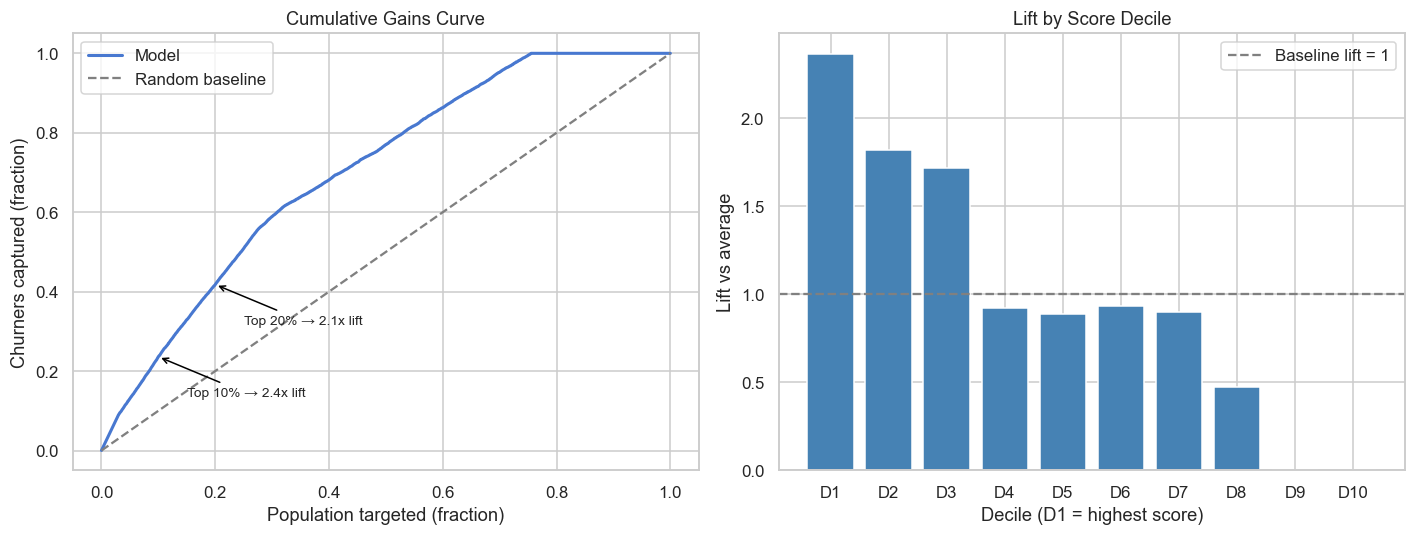


Decile Lift Table:
  decile  customers  churn_rate  avg_score   lift
0     D1       2000      0.7825     0.7835  2.361
1     D2       2000      0.6025     0.6096  1.818
2     D3       2000      0.5680     0.5458  1.714
3     D4       2000      0.3055     0.3286  0.922
4     D5       2000      0.2940     0.2995  0.887
5     D6       2000      0.3085     0.2959  0.931
6     D7       2000      0.2970     0.2925  0.896
7     D8       2000      0.1565     0.1572  0.472
8     D9       2000      0.0000     0.0076  0.000
9    D10       2000      0.0000     0.0075  0.000


In [24]:
# ============================================================
# CELL 23 — CUMULATIVE GAINS & LIFT
# ============================================================
print_section("20. CUMULATIVE GAINS & LIFT")

gains_df = test_results.sort_values("predicted_proba", ascending=False).reset_index(drop=True)
gains_df["cum_churners"]     = gains_df["actual_churn"].cumsum()
gains_df["population_pct"]   = (gains_df.index + 1) / len(gains_df)
gains_df["churn_capture_pct"] = gains_df["cum_churners"] / gains_df["actual_churn"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative gains
axes[0].plot(gains_df["population_pct"], gains_df["churn_capture_pct"],
             lw=2, label="Model")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
axes[0].set_xlabel("Population targeted (fraction)")
axes[0].set_ylabel("Churners captured (fraction)")
axes[0].set_title("Cumulative Gains Curve")
axes[0].legend()

# Lift at key deciles
for target_pct in [0.10, 0.20]:
    idx = int(target_pct * len(gains_df)) - 1
    lift = gains_df.iloc[idx]["churn_capture_pct"] / target_pct
    axes[0].annotate(f"Top {int(target_pct*100)}% → {lift:.1f}x lift",
                     xy=(target_pct, gains_df.iloc[idx]["churn_capture_pct"]),
                     xytext=(target_pct + 0.05, gains_df.iloc[idx]["churn_capture_pct"] - 0.1),
                     arrowprops=dict(arrowstyle="->", color="black"), fontsize=9)

# Decile lift table
overall_churn_rate = gains_df["actual_churn"].mean()
gains_df["decile"] = pd.qcut(
    gains_df["predicted_proba"].rank(method="first", ascending=False),
    10, labels=[f"D{i}" for i in range(1, 11)]
)
lift_table = (
    gains_df.groupby("decile")
    .agg(customers=("actual_churn", "size"),
         churn_rate=("actual_churn", "mean"),
         avg_score=("predicted_proba", "mean"))
    .reset_index()
)
lift_table["lift"] = (lift_table["churn_rate"] / overall_churn_rate).round(3)

# Plot decile lift bars
axes[1].bar(lift_table["decile"], lift_table["lift"], color="steelblue")
axes[1].axhline(1.0, linestyle="--", color="grey", label="Baseline lift = 1")
axes[1].set_xlabel("Decile (D1 = highest score)")
axes[1].set_ylabel("Lift vs average")
axes[1].set_title("Lift by Score Decile")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nDecile Lift Table:")
print(lift_table.round(4).to_string())

## 🎭 Section 24 — Uplift Modelling (Persuadability Analysis)

Standard churn prediction identifies *who will churn*. But not all churners are equally worth targeting. Uplift modelling separates customers into four strategic groups based on two dimensions:

**The 2×2 Uplift Matrix:**

| | High Churn Probability | Low Churn Probability |
|---|---|---|
| **Persuadable** | ✅ **ACT** — Highest priority; likely to churn AND likely to respond to intervention | 🌱 **NURTURE** — Not at risk now, but receptive to loyalty programmes |
| **Not Persuadable** | ⚠️ **MONITOR** — Will likely churn regardless of intervention (sunk cost) | ✅ **IGNORE** — Loyal and won't churn either way |

**Persuadability proxy:**  
Without a proper A/B test, we proxy persuadability using **tenure** — newer customers are more likely to respond to an offer because they haven't yet cemented their dissatisfaction. Long-tenure churners (the "Decided Churner" quadrant) may have already made their decision and are harder to retain.

> ⚠️ **Important caveat:** This is a *proxy*, not a causal uplift model. A proper uplift model requires randomised experiment data — a treatment group that received the intervention and a control group that didn't. Without this, we're estimating treatment effect, not measuring it. See the next-steps section for the path to proper causal modelling.


In [25]:
# ============================================================
# CELL 24 — UPLIFT / PERSUADABLE CHURN
# ============================================================
print_section("21. UPLIFT MODELLING (Simplified Treatment Effect Proxy)")

print(
    "\n⚠  Full uplift modelling requires a randomised experiment (treated vs control). "
    "Here we apply a simplified proxy: separate customers into four quadrants based on "
    "(a) predicted churn probability and (b) assumed retention persuadability, \n"
    "which can be proxied by tenure (newer customers are more persuadable) or by segment."
)

# Proxy persuadability via tenure quantile (lower tenure = more persuadable)
if "Tenure" in test_results.columns:
    tenure_median = test_results["Tenure"].median()
    test_results["persuadability"] = np.where(
        test_results["Tenure"] <= tenure_median, "High", "Low"
    )

    test_results["uplift_segment"] = np.select(
        [
            (test_results["predicted_proba"] >= best_threshold) & (test_results["persuadability"] == "High"),
            (test_results["predicted_proba"] >= best_threshold) & (test_results["persuadability"] == "Low"),
            (test_results["predicted_proba"] <  best_threshold) & (test_results["persuadability"] == "High"),
            (test_results["predicted_proba"] <  best_threshold) & (test_results["persuadability"] == "Low"),
        ],
        [
            "Persuadable Churner (ACT)",    # ← highest priority
            "Decided Churner (MONITOR)",    # ← cost to retain may be high
            "Safe + Persuadable (NURTURE)", # ← not churning but could be won over
            "Safe + Committed (IGNORE)",    # ← lowest priority
        ]
    )

    uplift_summary = (
        test_results.groupby("uplift_segment")
        .agg(
            customers=("actual_churn", "size"),
            actual_churn_rate=("actual_churn", "mean"),
            avg_prob=("predicted_proba", "mean"),
            avg_monthly_charge=("MonthlyCharges", "mean")
        )
        .reset_index()
        .sort_values("actual_churn_rate", ascending=False)
    )
    print("\nUplift segments:")
    print(uplift_summary.round(4).to_string())
else:
    print("'Tenure' column not found; uplift segmentation skipped.")

print(
    "\n→ To build a proper uplift model, you need A/B test data (intervention vs control). "
    "Approaches include Transformed Outcome Trees, Meta-learners (S-, T-, X-learner), "
    "or Causal Forests."
)


  21. UPLIFT MODELLING (Simplified Treatment Effect Proxy)

⚠  Full uplift modelling requires a randomised experiment (treated vs control). Here we apply a simplified proxy: separate customers into four quadrants based on (a) predicted churn probability and (b) assumed retention persuadability, 
which can be proxied by tenure (newer customers are more persuadable) or by segment.

Uplift segments:
                 uplift_segment  customers  actual_churn_rate  avg_prob  avg_monthly_charge
1     Persuadable Churner (ACT)       4376             0.6511    0.6464             93.3476
0     Decided Churner (MONITOR)       2054             0.5993    0.5922            124.7545
2     Safe + Committed (IGNORE)       7904             0.1880    0.1910             68.7404
3  Safe + Persuadable (NURTURE)       5666             0.1876    0.1943             69.7633

→ To build a proper uplift model, you need A/B test data (intervention vs control). Approaches include Transformed Outcome Trees, Meta-lea

## 💼 Section 25 — Retention Strategy Simulation

We now stress-test multiple campaign scenarios to find the strategy that maximises **net economic value** (saved revenue minus campaign cost) across different assumptions.

**Simulation dimensions:**
- **Target fraction (2%–20%):** How much of the customer base to contact
- **Campaign cost ($10–$30/customer):** Varies by channel (automated email = cheap; personal call + discount = expensive)
- **Retention success rate (10%–30%):** What fraction of contacted at-risk customers actually stay

**Key insight — the sweet spot:**  
There is an optimal target fraction beyond which the **marginal gain from contacting more customers is less than the marginal cost**. This happens when we start including customers with low churn probability — the signal degrades, and we pay to "retain" customers who would have stayed anyway.

**Break-even line:**  
The red dashed line on the net value plot marks zero — campaigns below this line destroy value even if some customers are retained. This is the minimum performance bar for any retention programme.

> 💡 **Operationalising the simulation:** The "best strategy" output from this cell is a direct recommendation to the campaign manager: "Target the top X% of customers, budget $Y per customer, expect Z% retention rate, projected net value $W." This bridges the gap between data science and operational execution.



  22. MULTI-SCENARIO RETENTION STRATEGY SIMULATION
Top 10 strategies by expected net value:
 target_fraction  n_targeted  cost_per_customer  retention_success_rate  actual_churn_rate_in_tgt  total_campaign_cost  expected_saved_revenue  expected_net_value  roi_pct
            0.20        4000                 10                    0.30                      0.69                40000                87447.81            47447.81   118.62
            0.15        3000                 10                    0.30                      0.73                30000                64988.65            34988.65   116.63
            0.20        4000                 10                    0.25                      0.69                40000                72873.18            32873.18    82.18
            0.15        3000                 10                    0.25                      0.73                30000                54157.20            24157.20    80.52
            0.10        2000                 10

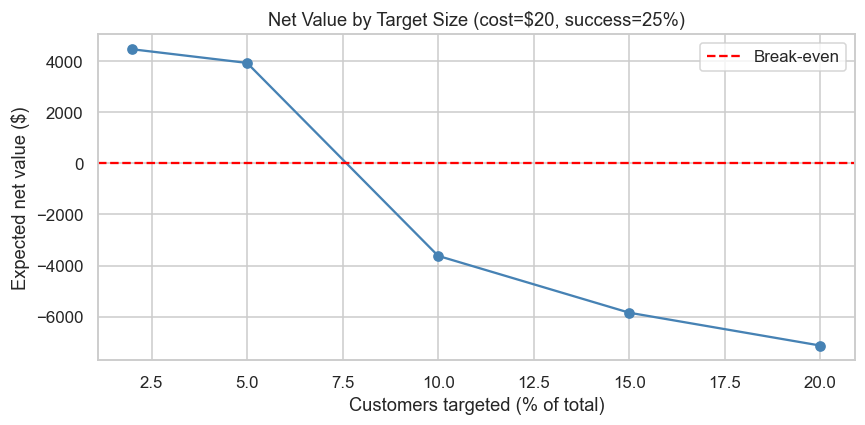

In [26]:
# ============================================================
# CELL 25 — RETENTION STRATEGY SIMULATION
# ============================================================
print_section("22. MULTI-SCENARIO RETENTION STRATEGY SIMULATION")

strategy_results = []

for frac in TARGET_FRACTIONS:
    n_target = int(len(test_results) * frac)
    targeted_base = test_results.nlargest(n_target, "predicted_proba").copy()
    actual_churn_rate_in_target = targeted_base["actual_churn"].mean()
    targeted_revenue = targeted_base["MonthlyCharges"].sum()

    for cost in CAMPAIGN_COST_OPTIONS:
        for success_rate in RETENTION_SUCCESS_RATES:
            saved_customers = targeted_base["actual_churn"] * success_rate
            expected_saved_revenue = (saved_customers * targeted_base["MonthlyCharges"]).sum()
            total_cost = cost * n_target
            net_value  = expected_saved_revenue - total_cost
            roi_pct    = (net_value / total_cost * 100) if total_cost > 0 else 0

            strategy_results.append({
                "target_fraction":          frac,
                "n_targeted":               n_target,
                "cost_per_customer":        cost,
                "retention_success_rate":   success_rate,
                "actual_churn_rate_in_tgt": actual_churn_rate_in_target,
                "total_campaign_cost":      total_cost,
                "expected_saved_revenue":   expected_saved_revenue,
                "expected_net_value":        net_value,
                "roi_pct":                  roi_pct
            })

strategy_df = pd.DataFrame(strategy_results).sort_values("expected_net_value", ascending=False)
print("Top 10 strategies by expected net value:")
print(strategy_df.head(10).round(2).to_string(index=False))

best_strategy = strategy_df.iloc[0]
print("\nBest strategy:")
print(best_strategy.round(2).to_string())

# Net value sensitivity plot
plot_subset = strategy_df[
    (strategy_df["cost_per_customer"] == MONTHLY_RETENTION_CAMPAIGN_COST) &
    (strategy_df["retention_success_rate"] == 0.25)
].sort_values("target_fraction")

if not plot_subset.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(plot_subset["target_fraction"] * 100, plot_subset["expected_net_value"],
            marker="o", color="steelblue")
    ax.axhline(0, linestyle="--", color="red", label="Break-even")
    ax.set_xlabel("Customers targeted (% of total)")
    ax.set_ylabel("Expected net value ($)")
    ax.set_title(f"Net Value by Target Size (cost=${MONTHLY_RETENTION_CAMPAIGN_COST}, success=25%)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 🗺️ Section 26 — Risk-Value Segmentation Matrix

Not all high-risk customers deserve the same intervention. A customer with 80% churn probability but $30/month spend is far less valuable to retain than one with 60% churn probability and $120/month spend.

**The 2×2 Priority Matrix:**

| | High Value ($) | Medium Value | Low Value ($) |
|---|---|---|---|
| **Critical Risk (>75%)** | 🔴 **Top Priority** — Immediate personal outreach | 🟠 High priority | 🟡 Low-cost outreach |
| **High Risk (50–75%)** | 🟠 High priority | 🟡 Moderate priority | ⚪ Low priority |
| **Medium Risk (25–50%)** | 🟡 Proactive loyalty | ⚪ Passive monitoring | ⚪ Ignore |
| **Low Risk (<25%)** | ⚪ Loyalty programmes | ⚪ Standard service | ⚪ Ignore |

**The heatmap** shows actual churn rates within each cell — validating that our risk bands are well-calibrated (Critical + High Value should show the highest churn).

**Monthly revenue at risk per cell:**  
This is the most directly actionable number for budget allocation. Prioritise cells where monthly revenue at risk is highest — these represent the greatest financial return on retention investment.

> 💡 **Operational rule:** Give the top-right cell (Critical Risk + High Value) to your best retention agents with full empowerment to offer significant discounts. Give the bottom-left cell (Low Risk + High Value) to a proactive loyalty team focused on deepening the relationship before risk emerges.



  23. RISK-VALUE SEGMENTATION


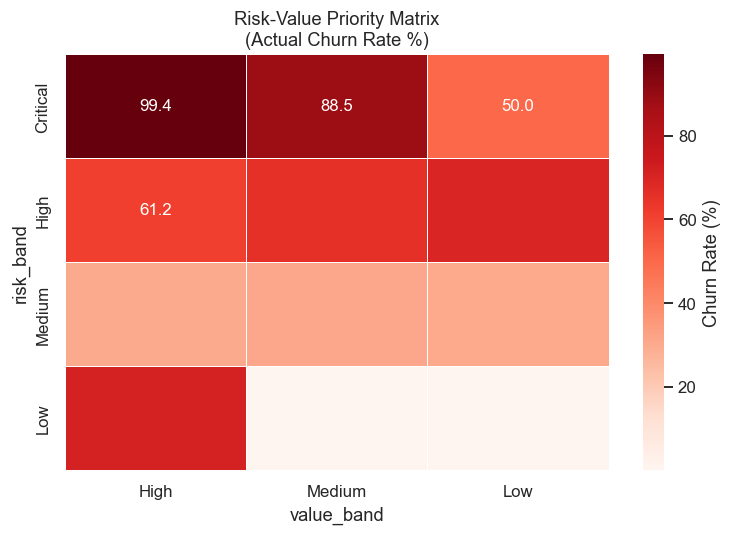

   risk_band value_band  customers  actual_churn_rate  avg_predicted_prob  avg_monthly_charge  monthly_revenue_at_risk
0   Critical       High        544             0.9945              0.9703            127.4627               67272.2910
2   Critical     Medium         87             0.8851              0.8932             97.4932                7626.1315
1   Critical        Low          2             0.5000              0.7632             29.7350                  45.3977
4       High        Low        589             0.6961              0.6978             33.8392               13920.3938
5       High     Medium        782             0.6573              0.6616             86.8691               44487.9107
3       High       High       3539             0.6120              0.6074            126.9022              272560.3515
10    Medium        Low       3481             0.3045              0.3127             33.1013               35862.7649
11    Medium     Medium       3534             0

In [27]:
# ============================================================
# CELL 26 — RISK-VALUE SEGMENTATION
# ============================================================
print_section("23. RISK-VALUE SEGMENTATION")

# Data-driven value quantiles
q33 = test_results["MonthlyCharges"].quantile(0.33)
q67 = test_results["MonthlyCharges"].quantile(0.67)

test_results["risk_band"]  = test_results["predicted_proba"].apply(risk_band)
test_results["value_band"] = test_results["MonthlyCharges"].apply(
    lambda x: value_band(x, q33, q67)
)

# Heatmap matrix: churn rate by risk × value
pivot = test_results.pivot_table(
    index="risk_band", columns="value_band",
    values="actual_churn", aggfunc="mean"
).fillna(0)

risk_order  = ["Critical", "High", "Medium", "Low"]
value_order = ["High", "Medium", "Low"]
pivot = pivot.reindex(index=[r for r in risk_order if r in pivot.index],
                      columns=[v for v in value_order if v in pivot.columns])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot * 100, annot=True, fmt=".1f", cmap="Reds",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Churn Rate (%)"})
ax.set_title("Risk-Value Priority Matrix\n(Actual Churn Rate %)")
plt.tight_layout()
plt.show()

# Full detail table
priority_matrix = (
    test_results.groupby(["risk_band", "value_band"])
    .agg(
        customers=("actual_churn", "size"),
        actual_churn_rate=("actual_churn", "mean"),
        avg_predicted_prob=("predicted_proba", "mean"),
        avg_monthly_charge=("MonthlyCharges", "mean"),
        monthly_revenue_at_risk=("monthly_revenue_at_risk", "sum")
    )
    .reset_index()
    .sort_values(["avg_predicted_prob", "avg_monthly_charge"], ascending=False)
)
print(priority_matrix.round(4).to_string())

## 📌 Section 27 — Business Recommendations

All prior analysis converges here into an actionable playbook. These recommendations are data-driven, operationally specific, and organised by time horizon and team.

**Framework for the recommendations:**
1. **Immediate Actions** — What the retention team can do this week with existing tools
2. **Model Deployment** — Technical requirements for putting the model into production
3. **Campaign Design** — Principles for maximising ROI on retention spend
4. **Next-Level Analytics** — Investment priorities for improving the model and measurement over the next 6–12 months

**Critical deployment recommendation — threshold:**  
The optimised threshold (identified in Cell 17) should replace the default 0.50 in production. Using 0.50 on an imbalanced churn problem typically misses half the churners that the model is technically capable of catching.

**Retraining cadence:**  
Customer behaviour evolves. A model trained on last year's data may miss the churn signals driven by a new competitor's offer, a price increase, or a network outage. Quarterly retraining with monitoring for concept drift (PSI — Population Stability Index) ensures ongoing relevance.


In [28]:
# ============================================================
# CELL 27 — BUSINESS RECOMMENDATIONS
# ============================================================
print_section("24. BUSINESS RECOMMENDATIONS")

recommendations = {
    "Immediate Actions": [
        f"Target top {int(best_strategy['target_fraction']*100)}% of customers ranked by churn probability × monthly revenue.",
        "Offer proactive retention to Critical + High-risk, High-value customers first.",
        "Review month-to-month contract customers — they show highest churn lift."
    ],
    "Model Deployment": [
        f"Use optimised threshold ({best_threshold}) rather than default 0.50.",
        "Verify calibration before using probabilities for revenue-at-risk estimates.",
        "Retrain model quarterly or after significant product/pricing changes."
    ],
    "Campaign Design": [
        "Limit broad campaigns where expected net value turns negative.",
        "For Low-value, high-risk customers, use low-cost automated outreach (email/SMS).",
        "Track retention success rate empirically and update campaign assumptions."
    ],
    "Next-Level Analytics": [
        "Run A/B test with treated vs control group to build true uplift model.",
        "Integrate call centre data, NPS, and service incident data as features.",
        "Consider temporal (time-series) modelling if monthly snapshots are available."
    ]
}

for category, items in recommendations.items():
    print(f"\n{'─'*50}")
    print(f"  {category}")
    print(f"{'─'*50}")
    for i, item in enumerate(items, 1):
        print(f"  {i}. {item}")


  24. BUSINESS RECOMMENDATIONS

──────────────────────────────────────────────────
  Immediate Actions
──────────────────────────────────────────────────
  1. Target top 20% of customers ranked by churn probability × monthly revenue.
  2. Offer proactive retention to Critical + High-risk, High-value customers first.
  3. Review month-to-month contract customers — they show highest churn lift.

──────────────────────────────────────────────────
  Model Deployment
──────────────────────────────────────────────────
  1. Use optimised threshold (0.35) rather than default 0.50.
  2. Verify calibration before using probabilities for revenue-at-risk estimates.
  3. Retrain model quarterly or after significant product/pricing changes.

──────────────────────────────────────────────────
  Campaign Design
──────────────────────────────────────────────────
  1. Limit broad campaigns where expected net value turns negative.
  2. For Low-value, high-risk customers, use low-cost automated outreach 

## ⚠️ Section 28 — Limitations & Honest Caveats

Every model has limitations. Stating them clearly is a mark of professional data science — and prevents the model from being misused or over-trusted.

**Most critical limitations:**

1. **No temporal validation** — We split randomly, not by time. This means the test set contains customers from the same time period as the training set. In production, the model will face *future* customers, whose behaviour may differ. A time-based split (e.g., train on Q1–Q3, test on Q4) is a more honest evaluation.

2. **SMOTE leakage risk** — If SMOTE is applied *before* cross-validation splitting, synthetic samples from the same original customer might appear in both train and validation folds, inflating metrics. Our pipeline applies SMOTE correctly inside each fold, but this is worth auditing carefully.

3. **Revenue model simplification** — We use `MonthlyCharges` as a proxy for customer value. In reality, customer value includes acquisition cost, support cost, upsell potential, and network effects (do they refer others?). A full CLV-based revenue model would change which customers to prioritise.

4. **Uplift is not causal** — Without a randomised experiment, we cannot claim that our interventions *cause* retention. We're identifying at-risk customers, not measuring the incremental lift of contacting them vs. not contacting them.


In [29]:
# ============================================================
# CELL 28 — LIMITATIONS & NEXT STEPS
# ============================================================
print_section("25. LIMITATIONS & NEXT STEPS")

limitations = [
    "No temporal holdout: future drift cannot be assessed without a time-based split.",
    "Synthetic/simplified data may not reflect real-world complexity (e.g., multi-product households).",
    "Revenue model uses only MonthlyCharges; CLV, acquisition cost, and support cost are excluded.",
    "Uplift is proxied, not modelled from a randomised experiment.",
    "SMOTE on pipeline may produce optimistic cross-validation results if folds are not correctly isolated.",
    "Model assumes a static threshold; dynamic or personalised thresholds may improve outcomes.",
]

next_steps = [
    "Integrate temporal validation: train on month T, evaluate on month T+3.",
    "Add customer-level CLV to revenue-at-risk computation.",
    "Run a genuine RCT to estimate causal retention effect.",
    "Explore deep learning (TabNet) or gradient boosting with advanced feature interactions.",
    "Monitor model performance (PSI, concept drift) post-deployment.",
]

print("\nLimitations:")
for i, lim in enumerate(limitations, 1):
    print(f"  {i}. {lim}")

print("\nNext Steps:")
for i, ns in enumerate(next_steps, 1):
    print(f"  {i}. {ns}")


  25. LIMITATIONS & NEXT STEPS

Limitations:
  1. No temporal holdout: future drift cannot be assessed without a time-based split.
  2. Synthetic/simplified data may not reflect real-world complexity (e.g., multi-product households).
  3. Revenue model uses only MonthlyCharges; CLV, acquisition cost, and support cost are excluded.
  4. Uplift is proxied, not modelled from a randomised experiment.
  5. SMOTE on pipeline may produce optimistic cross-validation results if folds are not correctly isolated.
  6. Model assumes a static threshold; dynamic or personalised thresholds may improve outcomes.

Next Steps:
  1. Integrate temporal validation: train on month T, evaluate on month T+3.
  2. Add customer-level CLV to revenue-at-risk computation.
  3. Run a genuine RCT to estimate causal retention effect.
  4. Explore deep learning (TabNet) or gradient boosting with advanced feature interactions.
  5. Monitor model performance (PSI, concept drift) post-deployment.


## 📊 Section 29 — Executive Summary

A single-table summary of the key performance indicators (KPIs) from the entire analysis — designed for stakeholder communication and dashboard integration.

**What makes this useful beyond a technical audience:**
- Model quality metrics (ROC-AUC, PR-AUC) translate to: *"This model ranks customers by risk significantly better than random selection"*
- Revenue at risk translates directly to: *"We've identified $X in monthly revenue that's at risk of being lost — here's how much is preventable"*
- Best strategy net value translates to: *"If we implement the recommended campaign, expected net economic return is $Y"*

This summary should be the basis for a recurring **model monitoring dashboard** post-deployment — tracked monthly alongside actual retention outcomes to measure real-world ROI and trigger retraining decisions.


In [30]:
# ============================================================
# CELL 29 — EXECUTIVE SUMMARY
# ============================================================
print_section("26. EXECUTIVE SUMMARY")

summary = {
    "best_model":                    best_model_name,
    "roc_auc_test":                  round(roc_auc, 4),
    "pr_auc_test":                   round(pr_auc, 4),
    "brier_score":                   round(brier, 4),
    "selected_threshold":            best_threshold,
    "total_monthly_revenue_at_risk":  round(total_monthly_risk, 2),
    "total_annualised_revenue_at_risk": round(total_annualised_risk, 2),
    "confirmed_monthly_revenue_loss": round(confirmed_monthly_loss, 2),
    "best_target_fraction":          best_strategy["target_fraction"],
    "best_campaign_cost_per_cust":   best_strategy["cost_per_customer"],
    "best_retention_success_rate":   best_strategy["retention_success_rate"],
    "best_expected_net_value":       round(best_strategy["expected_net_value"], 2),
    "best_roi_pct":                  round(best_strategy["roi_pct"], 1),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
print(summary_df.to_string())


  26. EXECUTIVE SUMMARY
                                             value
best_model                        GradientBoosting
roc_auc_test                                0.8051
pr_auc_test                                 0.6729
brier_score                                 0.1584
selected_threshold                            0.35
total_monthly_revenue_at_risk            626448.09
total_annualised_revenue_at_risk         7517377.1
confirmed_monthly_revenue_loss           628369.82
best_target_fraction                           0.2
best_campaign_cost_per_cust                   10.0
best_retention_success_rate                    0.3
best_expected_net_value                   47447.81
best_roi_pct                                 118.6


In [31]:
# ============================================================
# CELL 30 — SAVE ALL OUTPUTS
# ============================================================
print_section("27. SAVE OUTPUTS")

save_map = {
    "cv_model_comparison.csv":      cv_results_df,
    "threshold_comparison.csv":     threshold_df,
    "test_predictions.csv":         test_results,
    "strategy_simulation.csv":      strategy_df,
    "lift_table.csv":               lift_table,
    "risk_value_priority_matrix.csv": priority_matrix,
    "executive_summary.csv":        summary_df,
}

if feature_importance_df is not None:
    save_map["feature_importance.csv"] = feature_importance_df

if "uplift_segment" in test_results.columns:
    save_map["uplift_segments.csv"] = (
        test_results.groupby("uplift_segment")
        .agg(customers=("actual_churn", "size"),
             churn_rate=("actual_churn", "mean"),
             avg_monthly_charge=("MonthlyCharges", "mean"))
        .reset_index()
    )

for fname, data in save_map.items():
    path = OUTPUT_DIR / fname
    data.to_csv(path, index=(fname == "executive_summary.csv"))
    print(f"  Saved: {path}")

print(f"\n✓ All outputs written to: {OUTPUT_DIR.resolve()}")


  27. SAVE OUTPUTS
  Saved: outputs/cv_model_comparison.csv
  Saved: outputs/threshold_comparison.csv
  Saved: outputs/test_predictions.csv
  Saved: outputs/strategy_simulation.csv
  Saved: outputs/lift_table.csv
  Saved: outputs/risk_value_priority_matrix.csv
  Saved: outputs/executive_summary.csv
  Saved: outputs/feature_importance.csv
  Saved: outputs/uplift_segments.csv

✓ All outputs written to: /Users/kuanysh/Desktop/Data_Science/Data_analyst_portfolio/Telco_Customer_Churn_Data/outputs


---

## Project Complete

This notebook covers the full spectrum of a professional churn analysis:

| Section | What it shows |
|---|---|
| Data Quality | Missing data audit, deduplication, imbalance check |
| Feature Engineering | Domain-driven feature creation + interaction terms |
| EDA | Segment-level churn rates with lift annotations |
| Correlation & VIF | Multicollinearity detection |
| Statistical Tests | Chi-square + Cramér's V + Cohen's d |
| Survival Analysis | Kaplan-Meier curves + log-rank test |
| Imbalance Handling | class_weight vs SMOTE comparison |
| Model Comparison | 5 models × 5-fold CV with multiple metrics |
| Hyperparameter Tuning | GridSearchCV on best model |
| Calibration | Reliability diagram + Brier score |
| SHAP | Per-feature directional attribution |
| Error Analysis | FP/FN breakdown by segment |
| Uplift | Persuadable vs decided churner segmentation |
| Revenue at Risk | Probability-weighted monthly/annual estimates |
| Strategy Simulation | Multi-scenario ROI analysis |
| Risk-Value Matrix | Priority 2×2 heatmap |
| Recommendations | Immediate, deployment, campaign, and research actions |
